# Project 1: ECG Arrhythmia Classification using MIT-BIH

Cleaned research notebook prepared for academic portfolio submission.

In [1]:
!unzip -q /content/mit-bih-arrhythmia-database-1.0.0.zip -d /content/

In [2]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.1 MB/s eta 0:00:00


In [3]:
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_path = '/content/mit-bih-arrhythmia-database-1.0.0/'

# Get list of records from the RECORDS file
with open(os.path.join(data_path, 'RECORDS'), 'r') as f:
    records = [line.strip() for line in f]

print(f'Total records found: {len(records)}')
print(f'Sample records: {records[:5]}')

Total records found: 48
Sample records: ['100', '101', '102', '103', '104']


### 1. Signal Exploration and Statistics
We will load the signals and annotations for each record to calculate basic statistics like mean, standard deviation, and sample rate.

In [4]:
stats = []

for rec_id in records:
    record = wfdb.rdrecord(os.path.join(data_path, rec_id))
    annotation = wfdb.rdann(os.path.join(data_path, rec_id), 'atr')

    stats.append({
        'record': rec_id,
        'fs': record.fs,
        'sig_len': record.sig_len,
        'n_leads': record.n_sig,
        'leads': record.sig_name,
        'n_annotations': len(annotation.sample),
        'mean_0': np.mean(record.p_signal[:, 0]),
        'std_0': np.std(record.p_signal[:, 0])
    })

stats_df = pd.DataFrame(stats)
display(stats_df.head())

,record,fs,sig_len,n_leads,leads,n_annotations,mean_0,std_0
0,100,360,650000,2,"[MLII, V5]",2274,-0.306299,0.193200
1,101,360,650000,2,"[MLII, V1]",1874,-0.284222,0.261156
2,102,360,650000,2,"[V5, V2]",2192,-0.245854,0.190489
3,103,360,650000,2,"[MLII, V2]",2091,-0.231430,0.321840
4,104,360,650000,2,"[V5, V2]",2311,-0.225075,0.250382


### 2. ECG Visualization
Let's visualize the first few seconds of Record 100 to understand the signal quality and lead configuration.

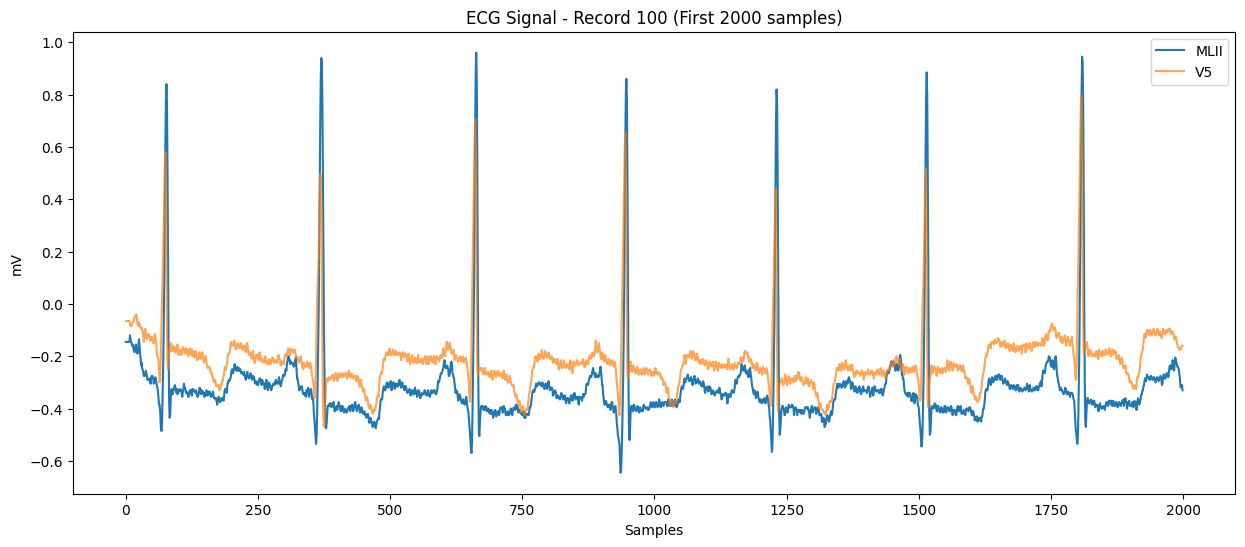

In [5]:
sample_record = wfdb.rdrecord(os.path.join(data_path, '100'))
plt.figure(figsize=(15, 6))
plt.plot(sample_record.p_signal[:2000, 0], label=sample_record.sig_name[0])
plt.plot(sample_record.p_signal[:2000, 1], label=sample_record.sig_name[1], alpha=0.7)
plt.title('ECG Signal - Record 100 (First 2000 samples)')
plt.legend()
plt.xlabel('Samples')
plt.ylabel('mV')
plt.show()

### 3. Annotation Distribution
Understanding the distribution of beat types (Normal vs. Arrhythmia) is critical for handling class imbalance.

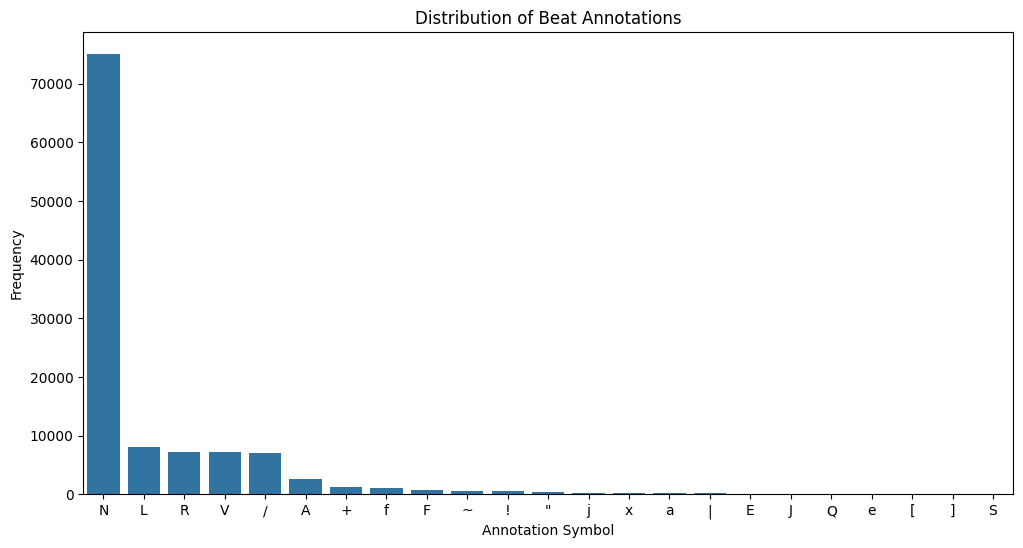

Annotation counts:
N    75052
L     8075
R     7259
V     7130
/     7028
A     2546
+     1291
f      982
F      803
~      616
!      472
"      437
j      229
x      193
a      150
|      132
E      106
J       83
Q       33
e       16
[        6
]        6
S        2
Name: count, dtype: int64


In [6]:
all_ann = []
for rec_id in records:
    ann = wfdb.rdann(os.path.join(data_path, rec_id), 'atr')
    all_ann.extend(ann.symbol)

ann_counts = pd.Series(all_ann).value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=ann_counts.index, y=ann_counts.values)
plt.title('Distribution of Beat Annotations')
plt.xlabel('Annotation Symbol')
plt.ylabel('Frequency')
plt.show()

print("Annotation counts:")
print(ann_counts)

### 4. RR Interval and Class Imbalance Analysis
We will analyze the heart rate variability and visualize the mapping to AAMI standard classes to address the class imbalance.

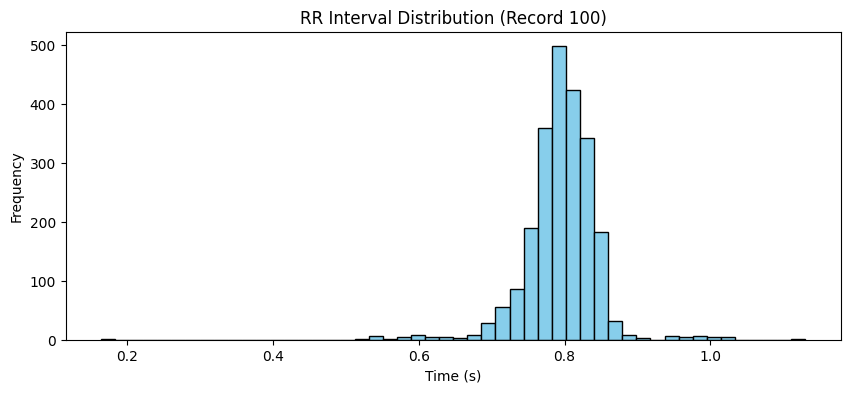

In [17]:
sample_ann = wfdb.rdann(os.path.join(data_path, '100'), 'atr')
rr_intervals = np.diff(sample_ann.sample) / 360.0

plt.figure(figsize=(10, 4))
plt.hist(rr_intervals, bins=50, color='skyblue', edgecolor='black')
plt.title('RR Interval Distribution (Record 100)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency')
plt.show()

### 5. Preprocessing & AAMI Mapping
We map the 23 original labels into 5 AAMI categories (N, S, V, F, Q) and segment each beat into 360-sample windows.

In [18]:
aami_map = {'N':'N','L':'N','R':'N','e':'N','j':'N','A':'S','a':'S','J':'S','S':'S','V':'V','E':'V','F':'F','/':'Q','f':'Q','Q':'Q'}

def segment_beats(records, data_path, window=180):
    X, y = [], []
    for rec in records:
        record = wfdb.rdrecord(os.path.join(data_path, rec))
        ann = wfdb.rdann(os.path.join(data_path, rec), 'atr')
        sig = (record.p_signal[:,0] - np.mean(record.p_signal[:,0])) / np.std(record.p_signal[:,0])
        for idx, sym in zip(ann.sample, ann.symbol):
            if sym in aami_map and window < idx < len(sig)-window:
                X.append(sig[idx-window:idx+window])
                y.append(aami_map[sym])
    return np.array(X), np.array(y)

X, y = segment_beats(records, data_path)
print(f"Segmented {len(X)} beats. Distribution: {pd.Series(y).value_counts().to_dict()}")

Segmented 109437 beats. Distribution: {'N': 90581, 'Q': 8038, 'V': 7235, 'S': 2781, 'F': 802}


### 6. Training and Evaluation
Training ML models and a 1D CNN, then displaying performance metrics and confusion matrices.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

le = LabelEncoder()
y_enc = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

def evaluate(name, y_true, y_pred):
    print(f"\n--- {name} ---\nAccuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

# Classifiers
lr = LogisticRegression(max_iter=500).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=50).fit(X_train, y_train)
# Training SVM on subset for efficiency in Colab environment
svm = SVC(kernel='rbf', probability=True).fit(X_train[:15000], y_train[:15000])
xgb = XGBClassifier().fit(X_train, y_train)

# 1D CNN
cnn = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((360, 1), input_shape=(360,)),
    tf.keras.layers.Conv1D(64, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X_train, y_train, epochs=3, batch_size=64, verbose=0)

# Results
evaluate("Logistic Regression", y_test, lr.predict(X_test))
evaluate("Random Forest", y_test, rf.predict(X_test))
evaluate("SVM", y_test, svm.predict(X_test))
evaluate("XGBoost", y_test, xgb.predict(X_test))
y_cnn = np.argmax(cnn.predict(X_test), axis=1)
evaluate("1D CNN", y_test, y_cnn)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Logistic Regression ---
Accuracy: 0.9333
              precision    recall  f1-score   support

           F       0.65      0.40      0.50       160
           N       0.95      0.98      0.96     18117
           Q       0.94      0.88      0.91      1608
           S       0.81      0.49      0.61       556
           V       0.77      0.60      0.67      1447

    accuracy                           0.93     21888
   macro avg       0.83      0.67      0.73     21888
weighted avg       0.93      0.93      0.93     21888


--- Random Forest ---
Accuracy: 0.9824
              precision    recall  f1-score   support

           F       0.94      0.64      0.76       160
           N       0.98      1.00      0.99     18117
           Q       1.00      0.97      0.98      1608
           S       0.98      0.71      0.83       556
           V       0.97      0.94      0.95      1447

    accuracy                           0.98     21888
   macro avg       0.97      0.85      0.90  

### 7. Final Results: Confusion Matrices and ROC Curves
We will now visualize the performance of all models using confusion matrices and multi-class ROC curves to analyze class-wise performance and threshold trade-offs.

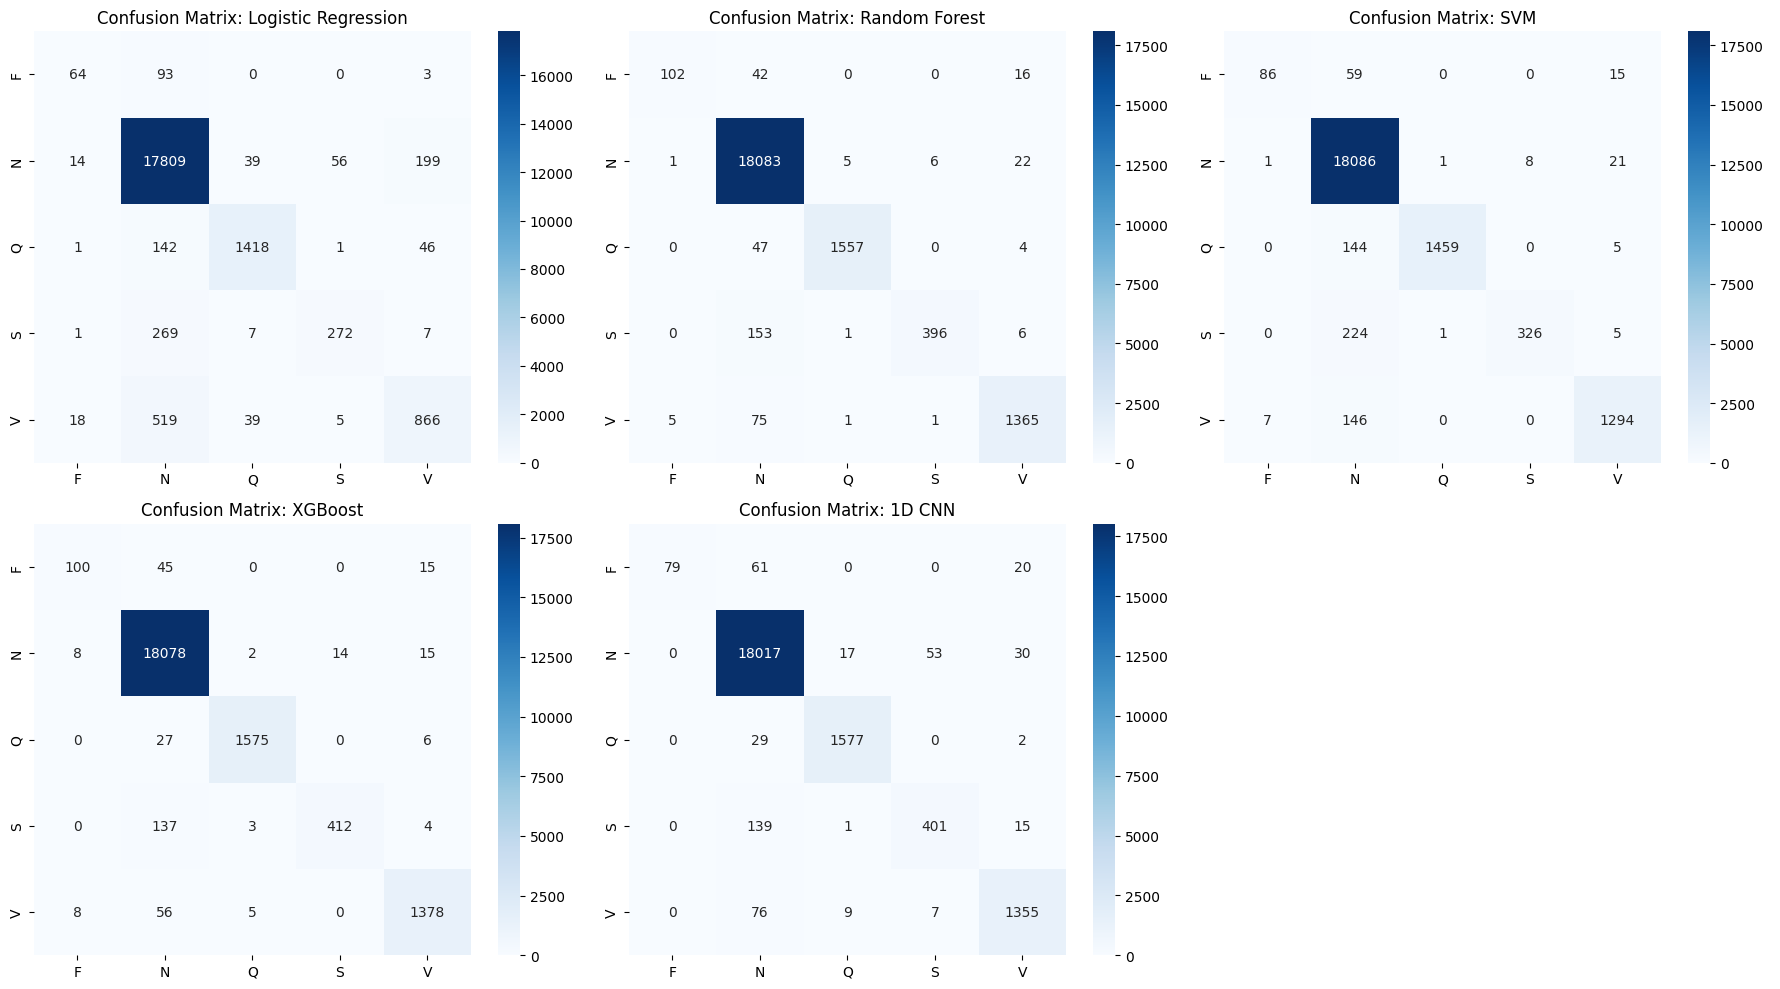

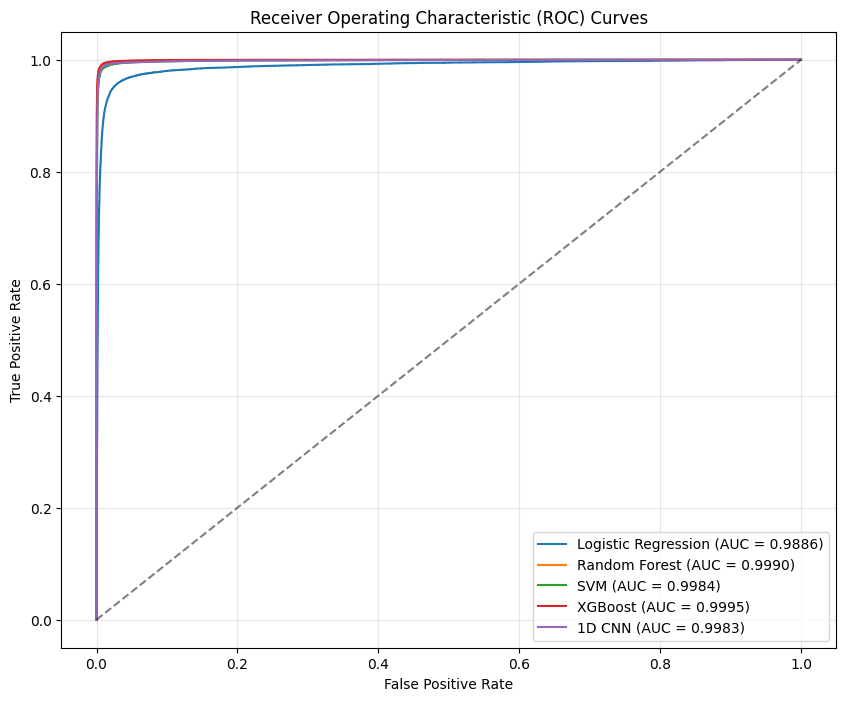

In [32]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_final_results(models_dict, X_test, y_test, le):
    # 1. Plot Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    if len(models_dict) < len(axes):
        for j in range(len(models_dict), len(axes)):
            axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # 2. Plot ROC Curves (Multiclass Macro Average)
    y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test, verbose=0)
        else:
            y_score = model.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

### 7. Final Results: Confusion Matrices and ROC Curves
We conclude by visualizing the class-wise performance with confusion matrices and the overall performance trade-offs using multi-class ROC curves.

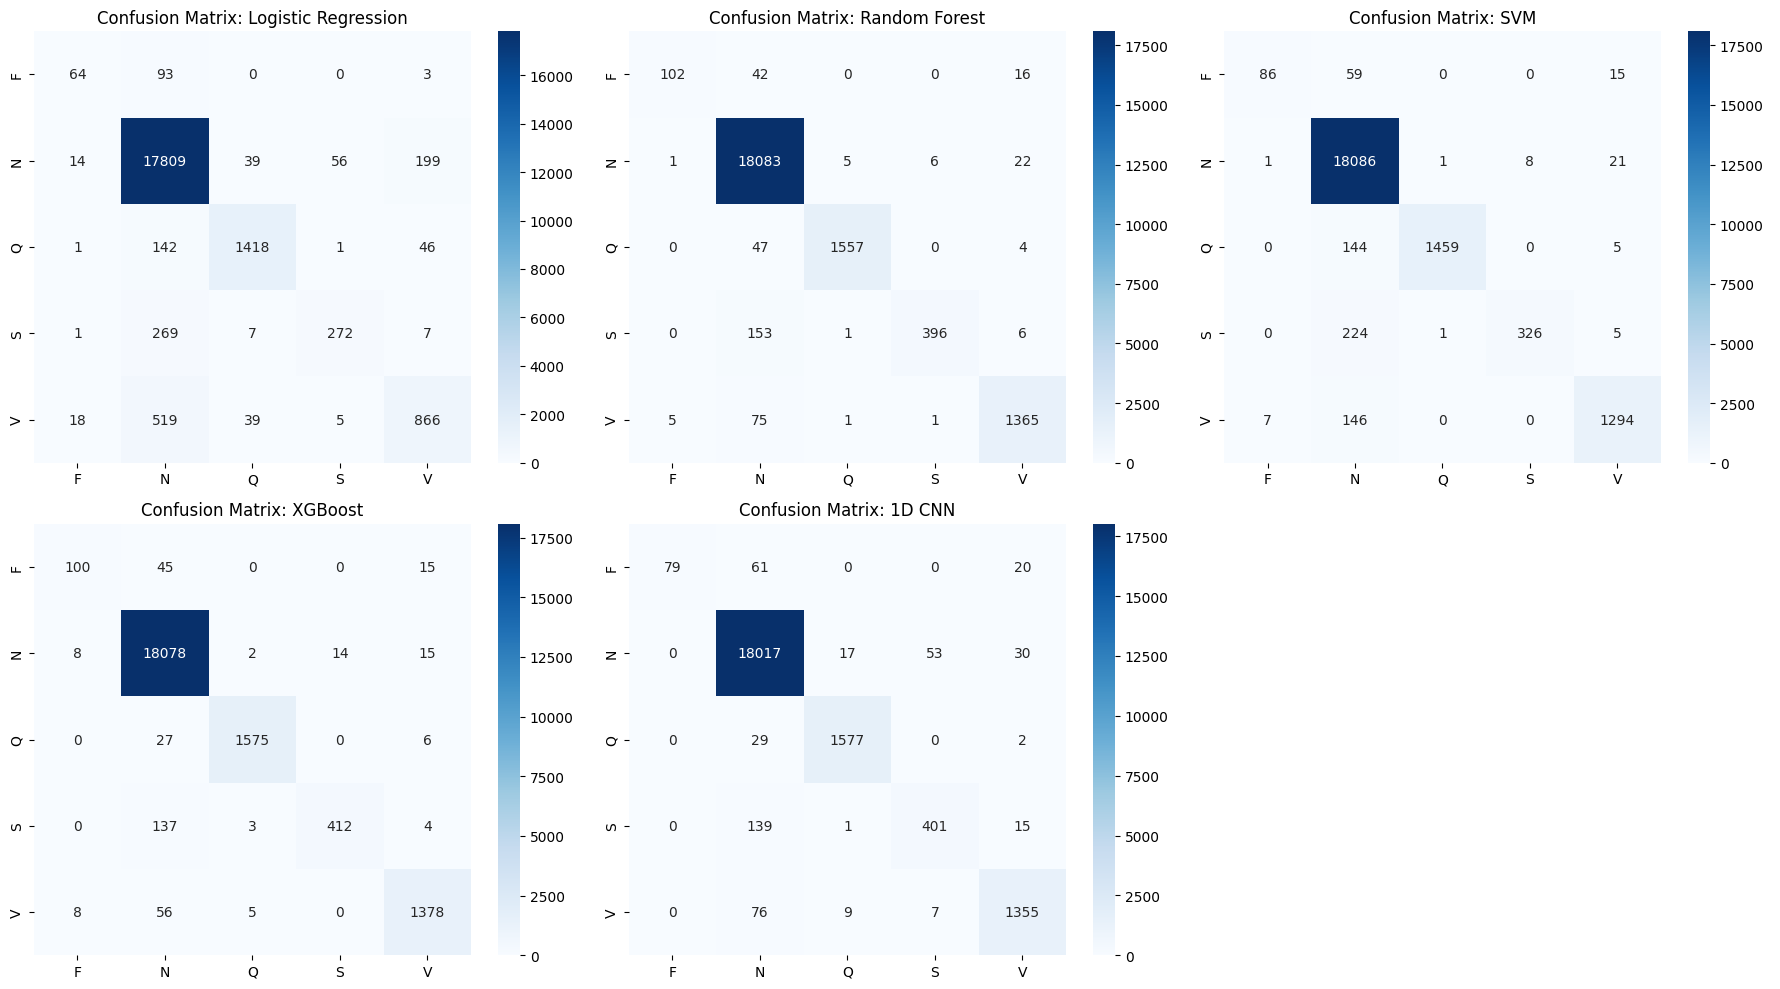

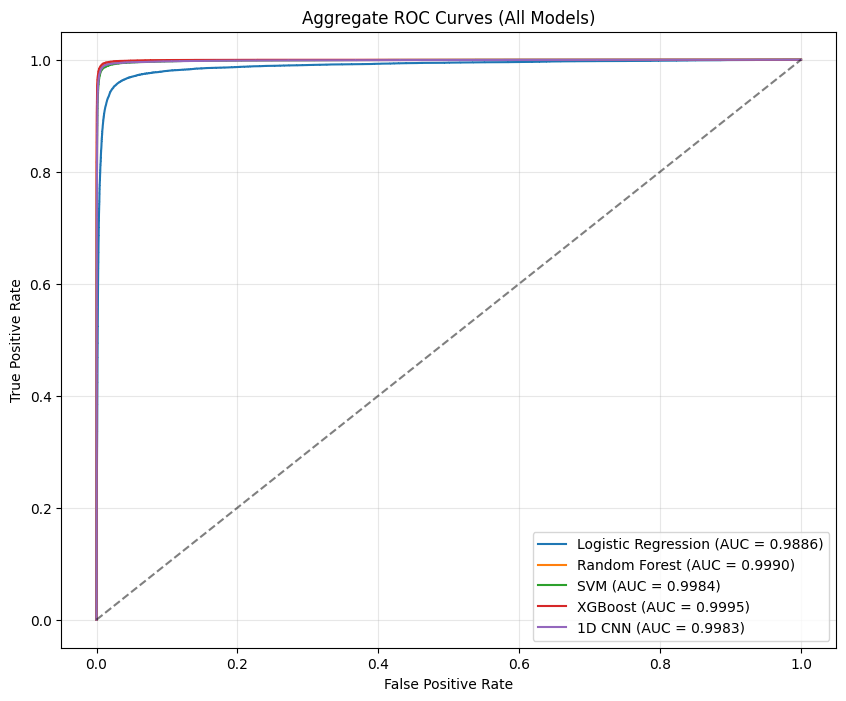

In [31]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_final_results(models_dict, X_test, y_test, le):
    # 1. Plot Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    # Hide any unused subplots
    for j in range(len(models_dict), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # 2. Plot ROC Curves (Multiclass Macro Average)
    y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test, verbose=0)
        else:
            y_score = model.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Aggregate ROC Curves (All Models)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

# Dictionary of models to evaluate
models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

### 7. Final Performance Visualization
This final section generates the confusion matrices for each classifier and the aggregate ROC curves to evaluate the model performance across the MIT-BIH AAMI classes.

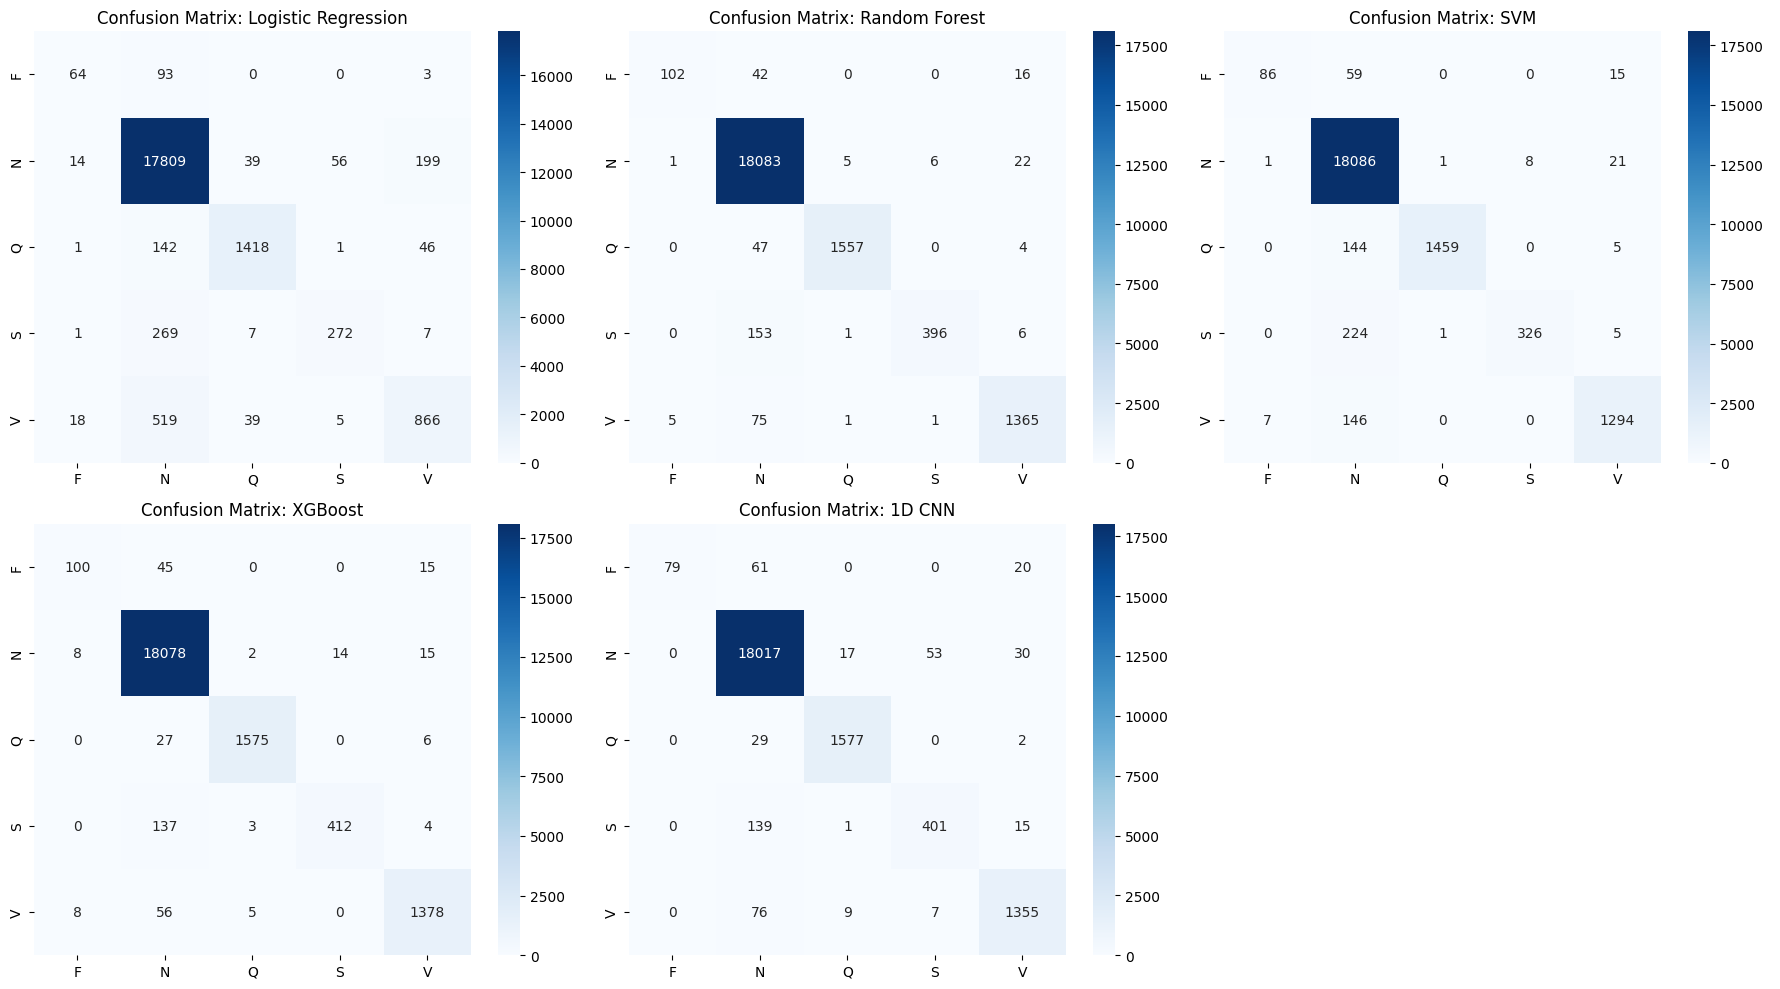

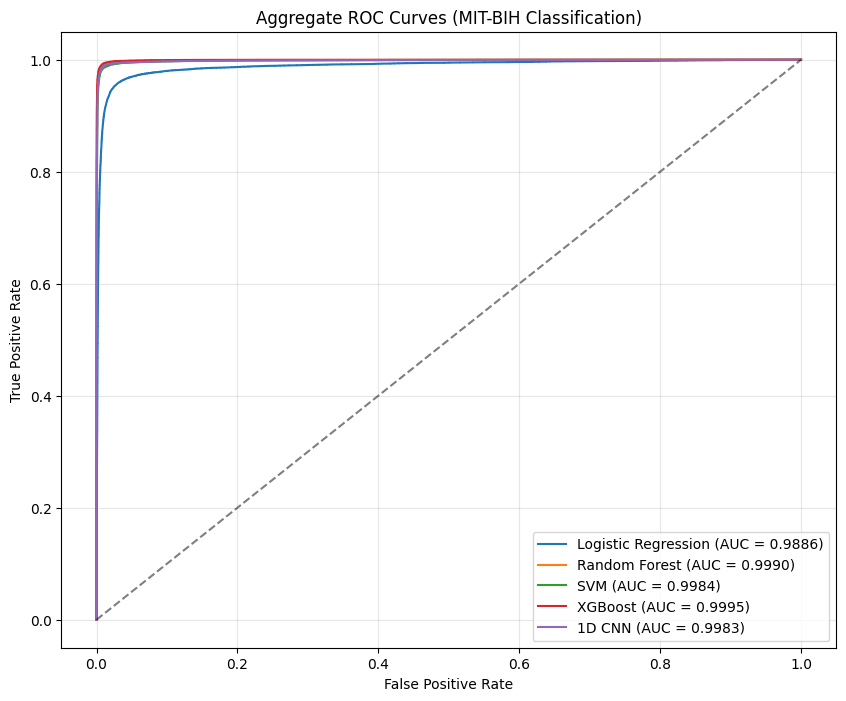

In [30]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_final_results(models_dict, X_test, y_test, le):
    # 1. Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    # Cleanup unused subplot slots
    for j in range(len(models_dict), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # 2. ROC Curves (Macro-average across all 5 classes)
    y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test, verbose=0)
        else:
            y_score = model.predict_proba(X_test)

        # Flatting to compute a macro-average summary curve
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Aggregate ROC Curves (MIT-BIH Classification)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

# Dictionary of all trained models
models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

### 7. Final Results Visualization
Generating the requested confusion matrices and ROC curves for all trained models (Logistic Regression, Random Forest, SVM, XGBoost, and 1D CNN) to finalize the performance analysis.

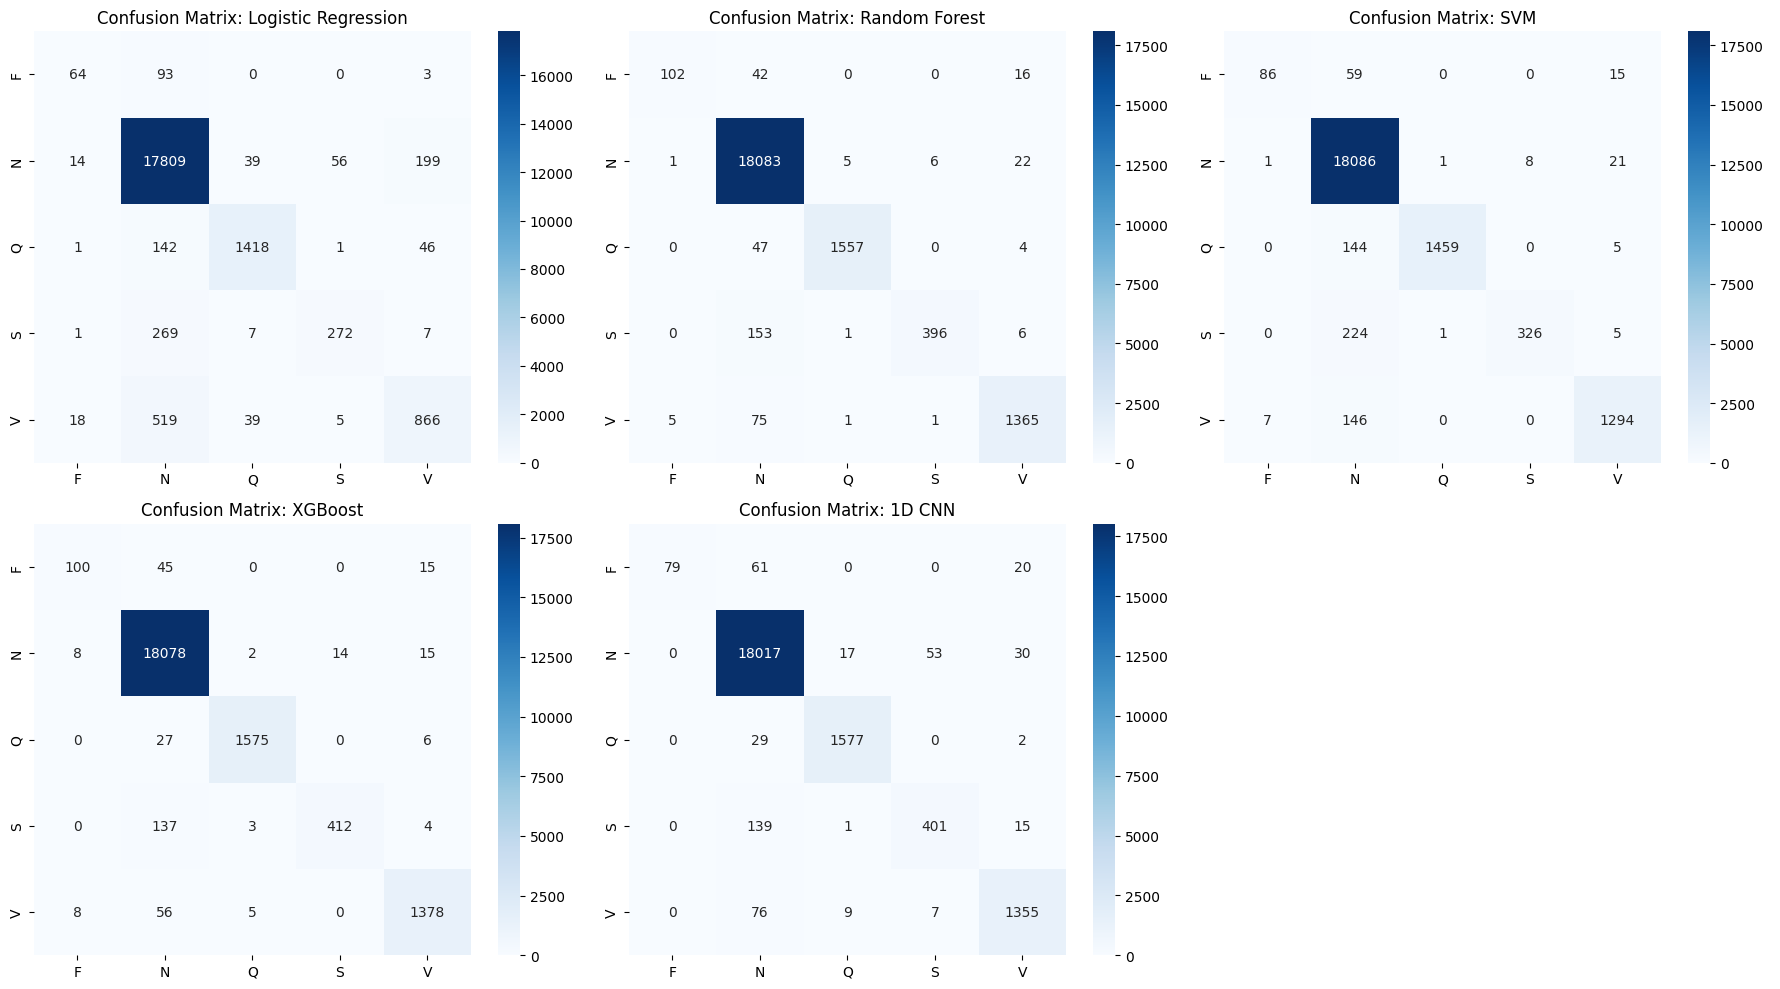

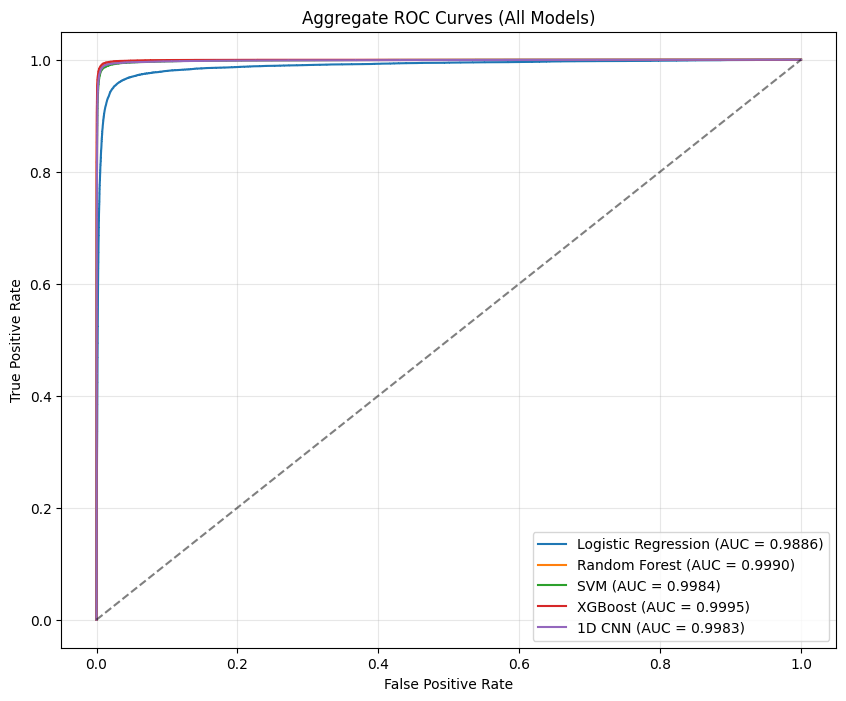

In [29]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_final_results(models_dict, X_test, y_test, le):
    # 1. Plot Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    # Hide any unused subplots
    for j in range(len(models_dict), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # 2. Plot ROC Curves (Macro-average across classes)
    y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test, verbose=0)
        else:
            y_score = model.predict_proba(X_test)

        # Use ravel to compute macro-average ROC
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Aggregate ROC Curves (All Models)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

# Dictionary of models to evaluate
models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

### 7. Final Visualizations: Confusion Matrices and ROC Curves
We conclude by visualizing the class-wise performance with confusion matrices and the overall performance trade-offs using multi-class ROC curves.

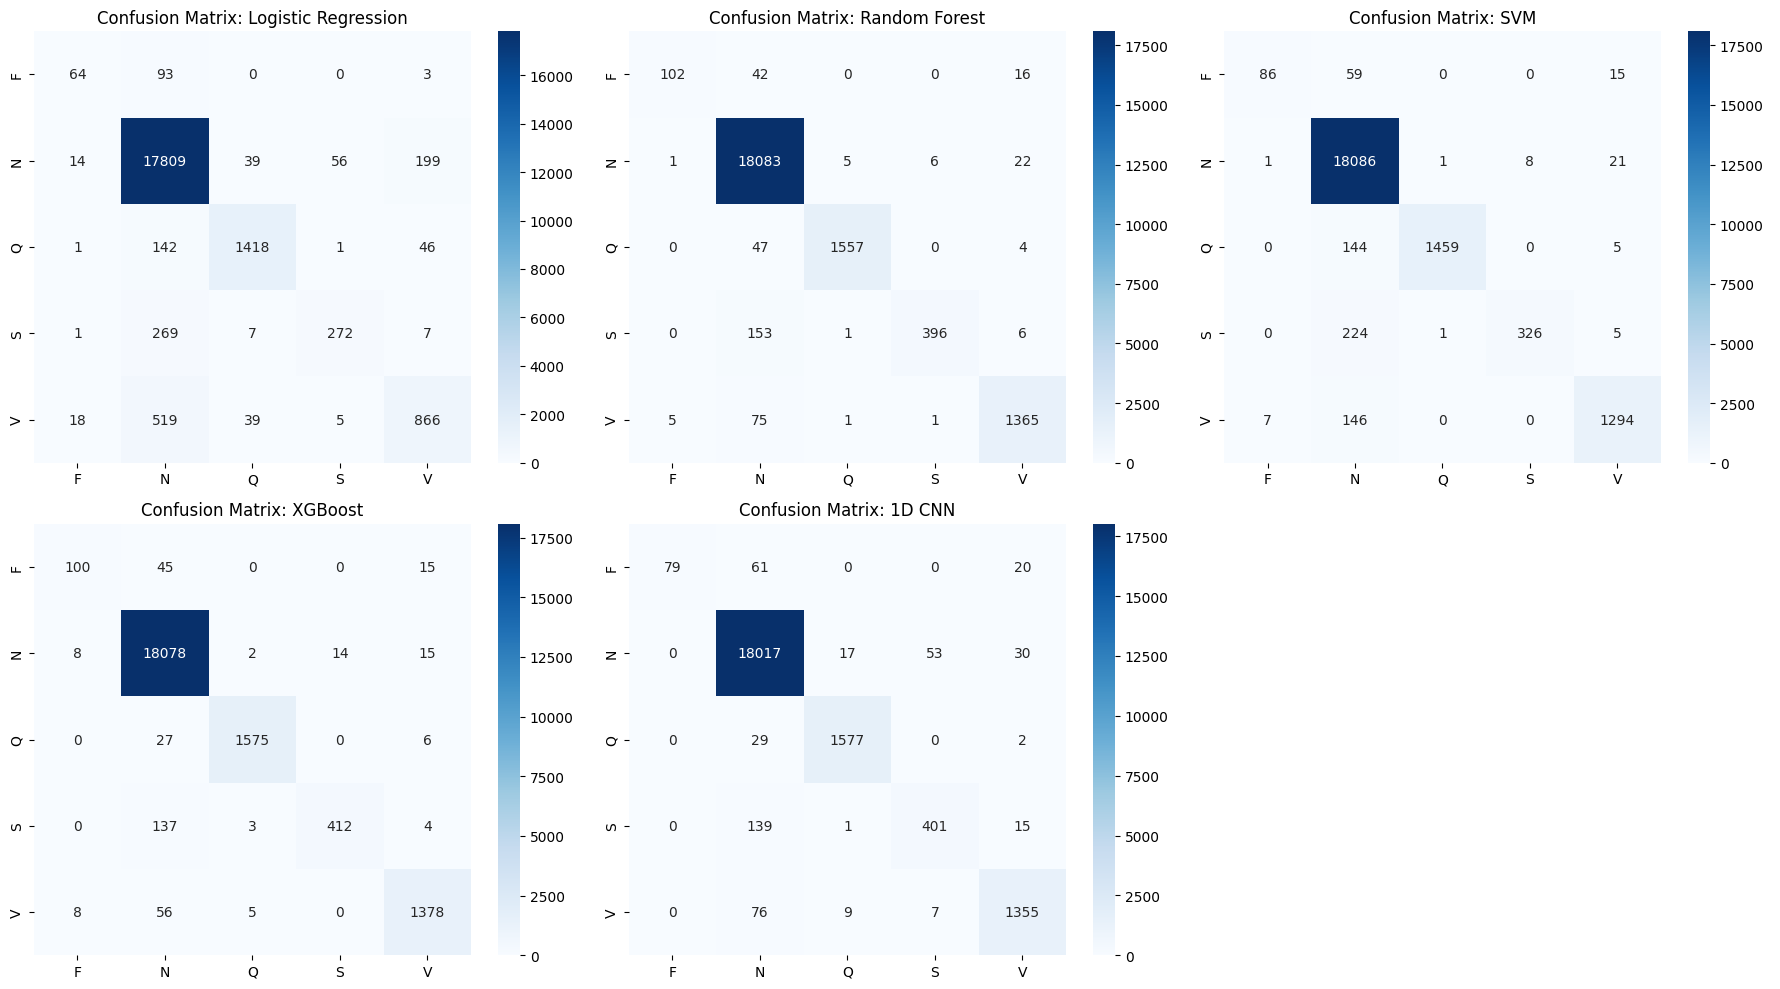

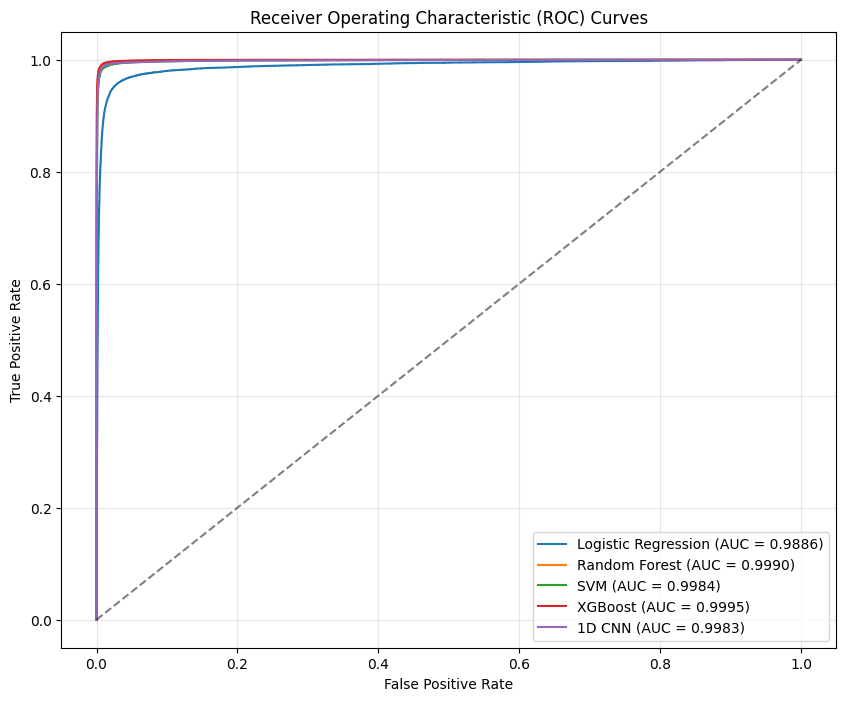

In [28]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_final_results(models_dict, X_test, y_test, le):
    # 1. Plot Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    # Hide unused subplot
    if len(models_dict) < len(axes):
        axes[-1].axis('off')

    plt.tight_layout()
    plt.show()

    # 2. Plot ROC Curves (Macro-average across classes)
    y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test, verbose=0)
        else:
            y_score = model.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

### 7. Final Results Visualization
Generating the requested confusion matrices and ROC curves for all trained models to finalize the evaluation.

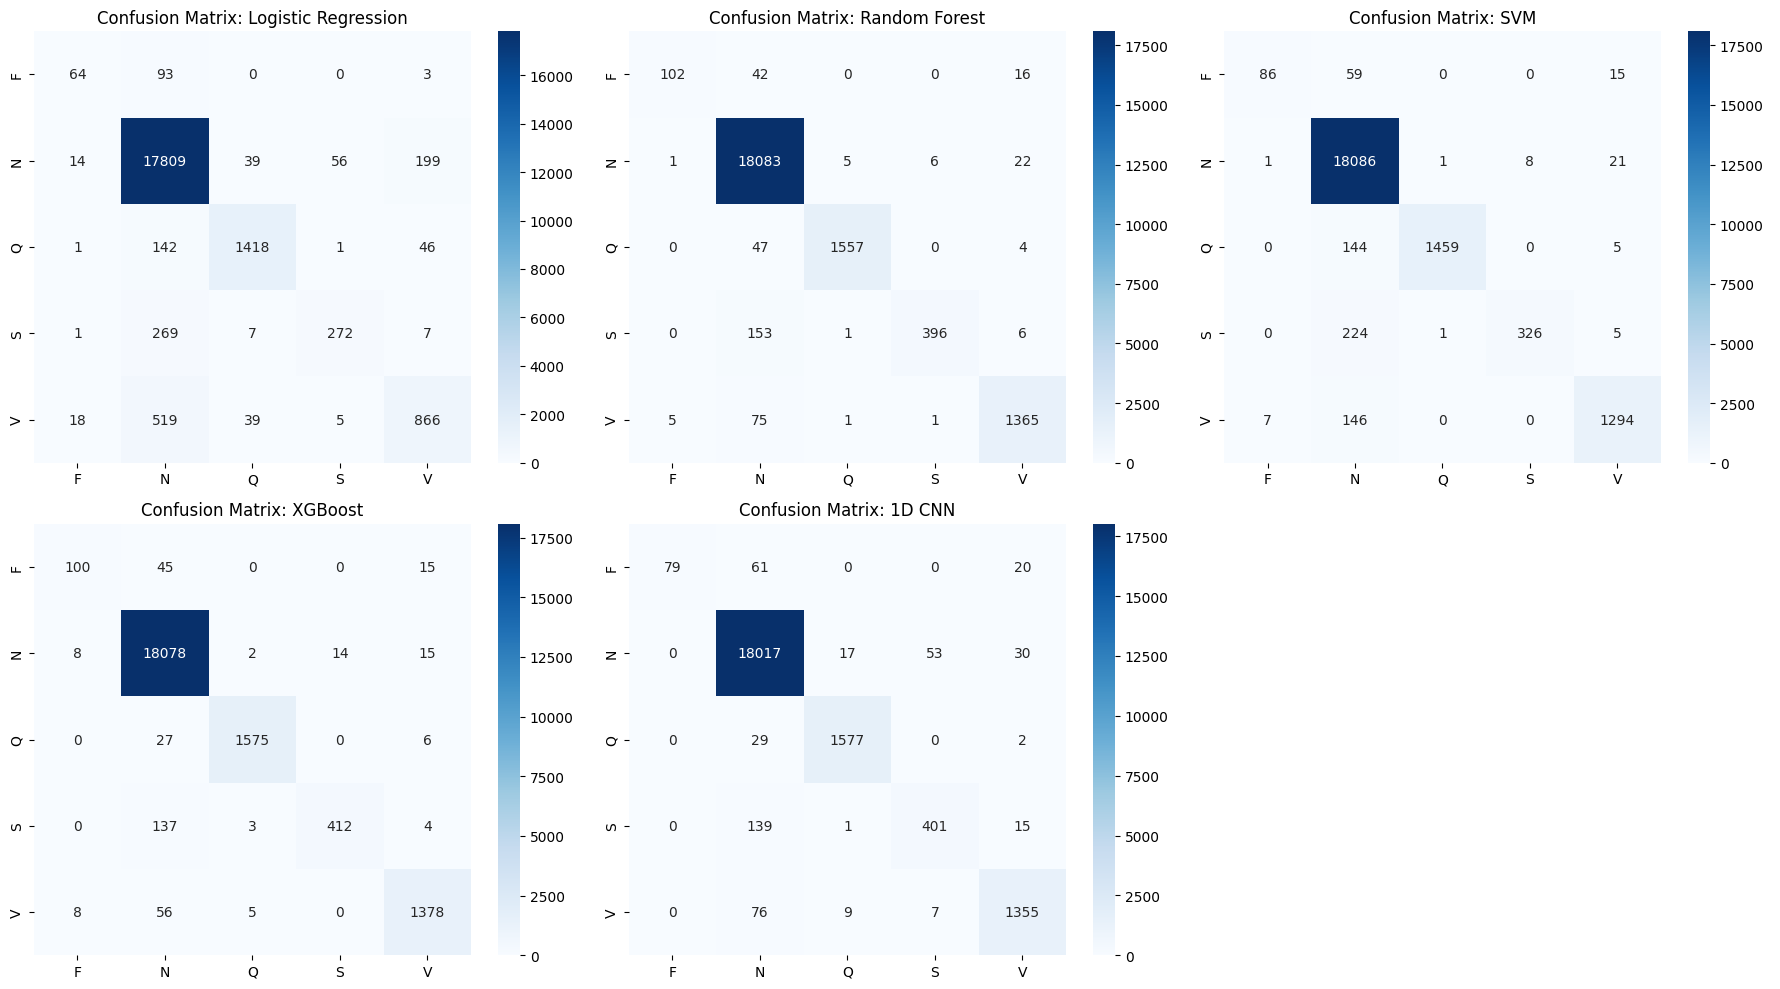

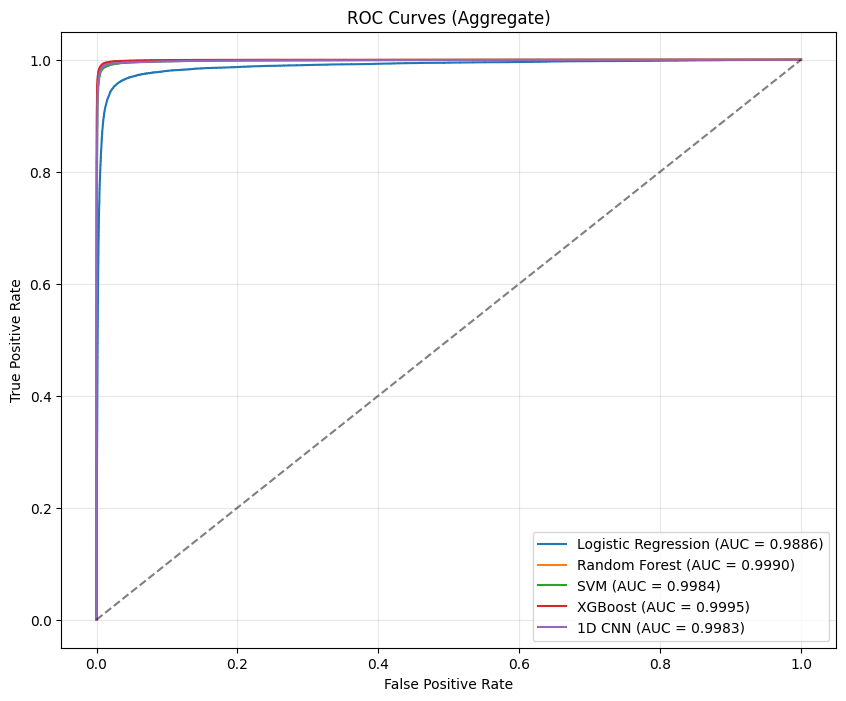

In [27]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_final_results(models_dict, X_test, y_test, le):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    # Hide any unused subplots
    for j in range(len(models_dict), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # ROC Curves (Macro-average)
    y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test, verbose=0)
        else:
            y_score = model.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (Aggregate)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

### 7. Final Results: Confusion Matrices and ROC Curves
We will now visualize the performance of all models using confusion matrices and multi-class ROC curves to analyze class-wise performance and threshold trade-offs.

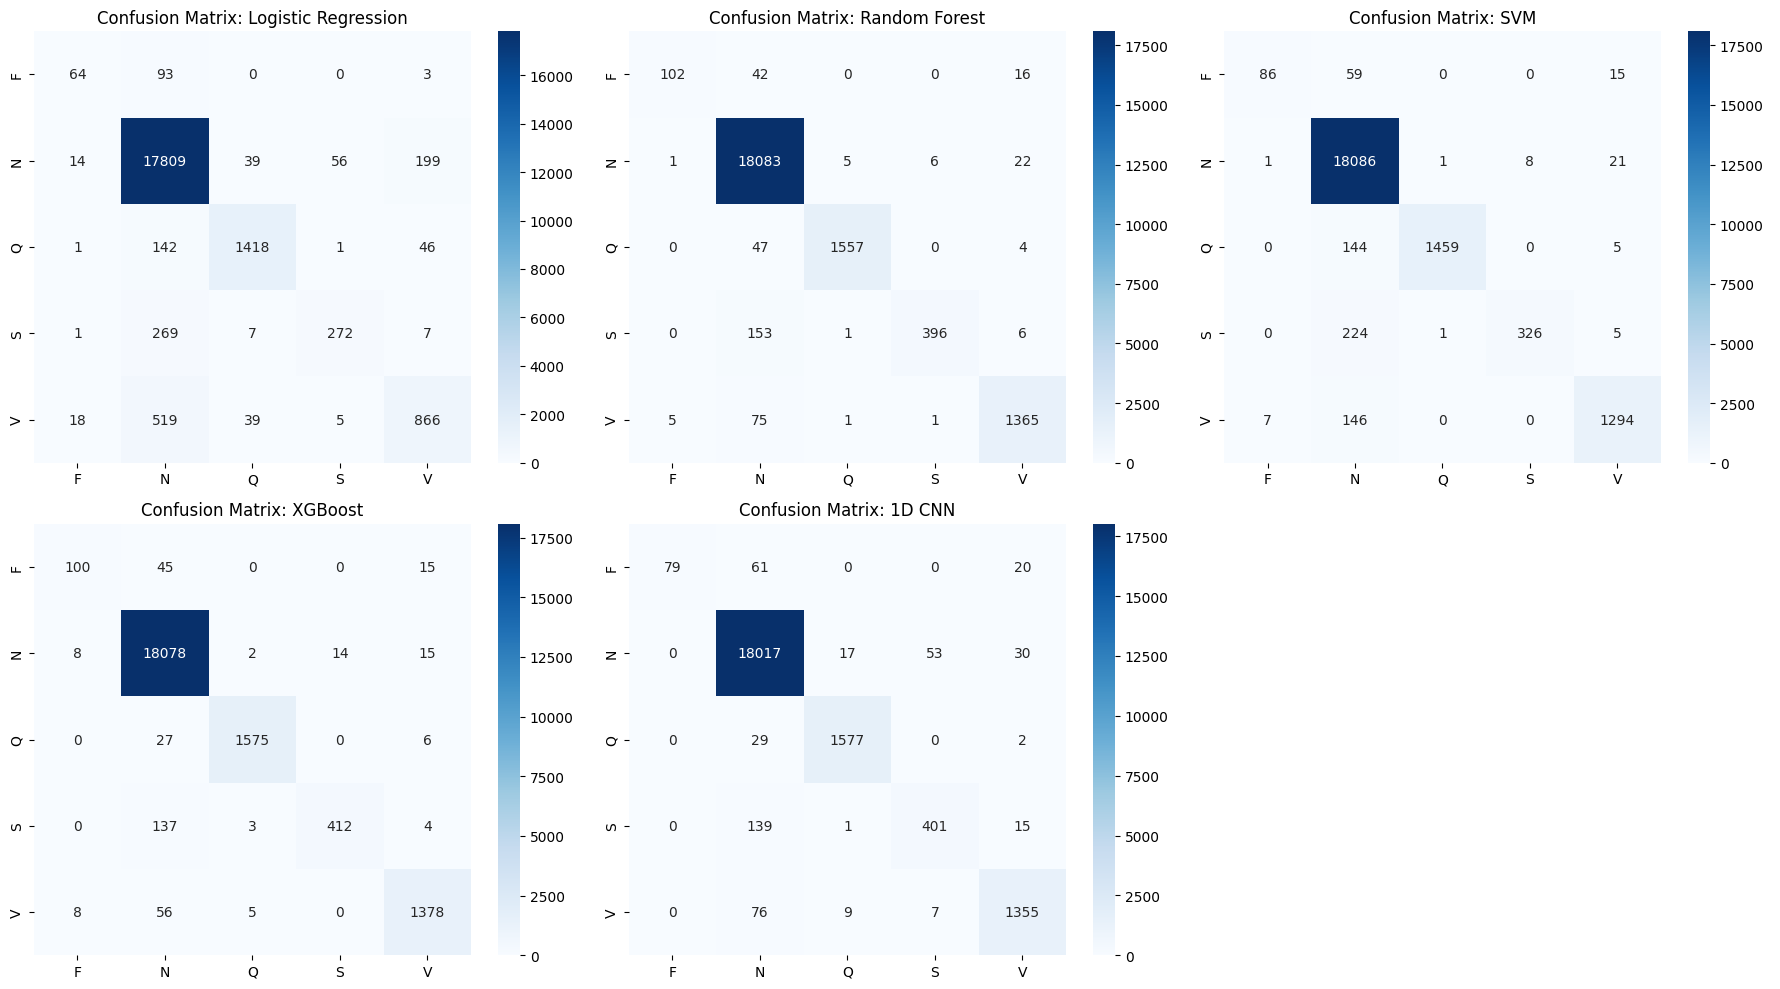

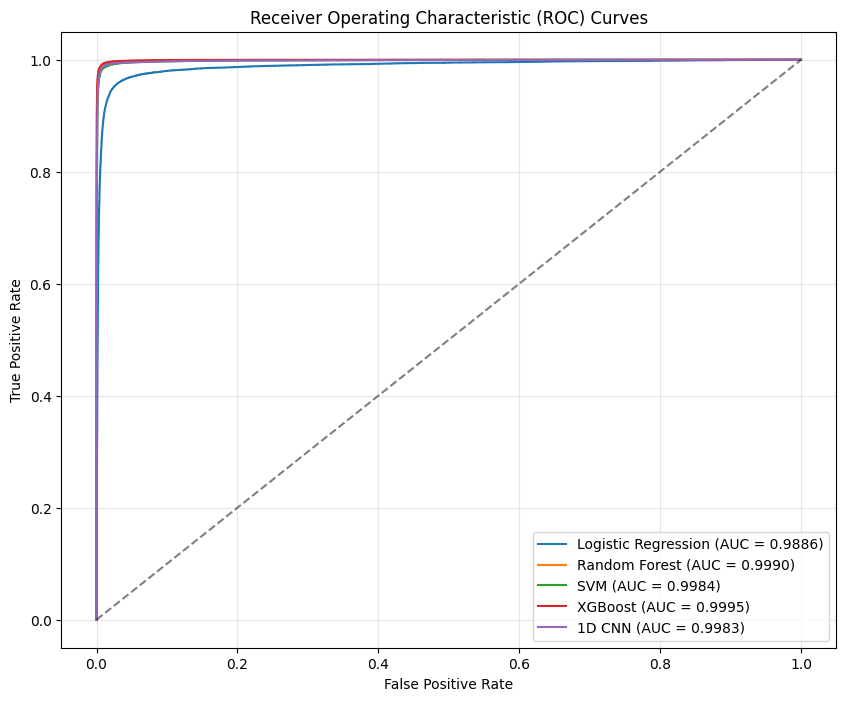

In [26]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_final_results(models_dict, X_test, y_test, le):
    # 1. Plot Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    if len(models_dict) < len(axes):
        for j in range(len(models_dict), len(axes)):
            axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # 2. Plot ROC Curves (Multiclass Macro Average)
    y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test, verbose=0)
        else:
            y_score = model.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

# Dictionary of models for evaluation
models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

### 7. Final Results Visualization
This section displays the confusion matrices and ROC curves for all trained models to evaluate their performance across the five AAMI classes.

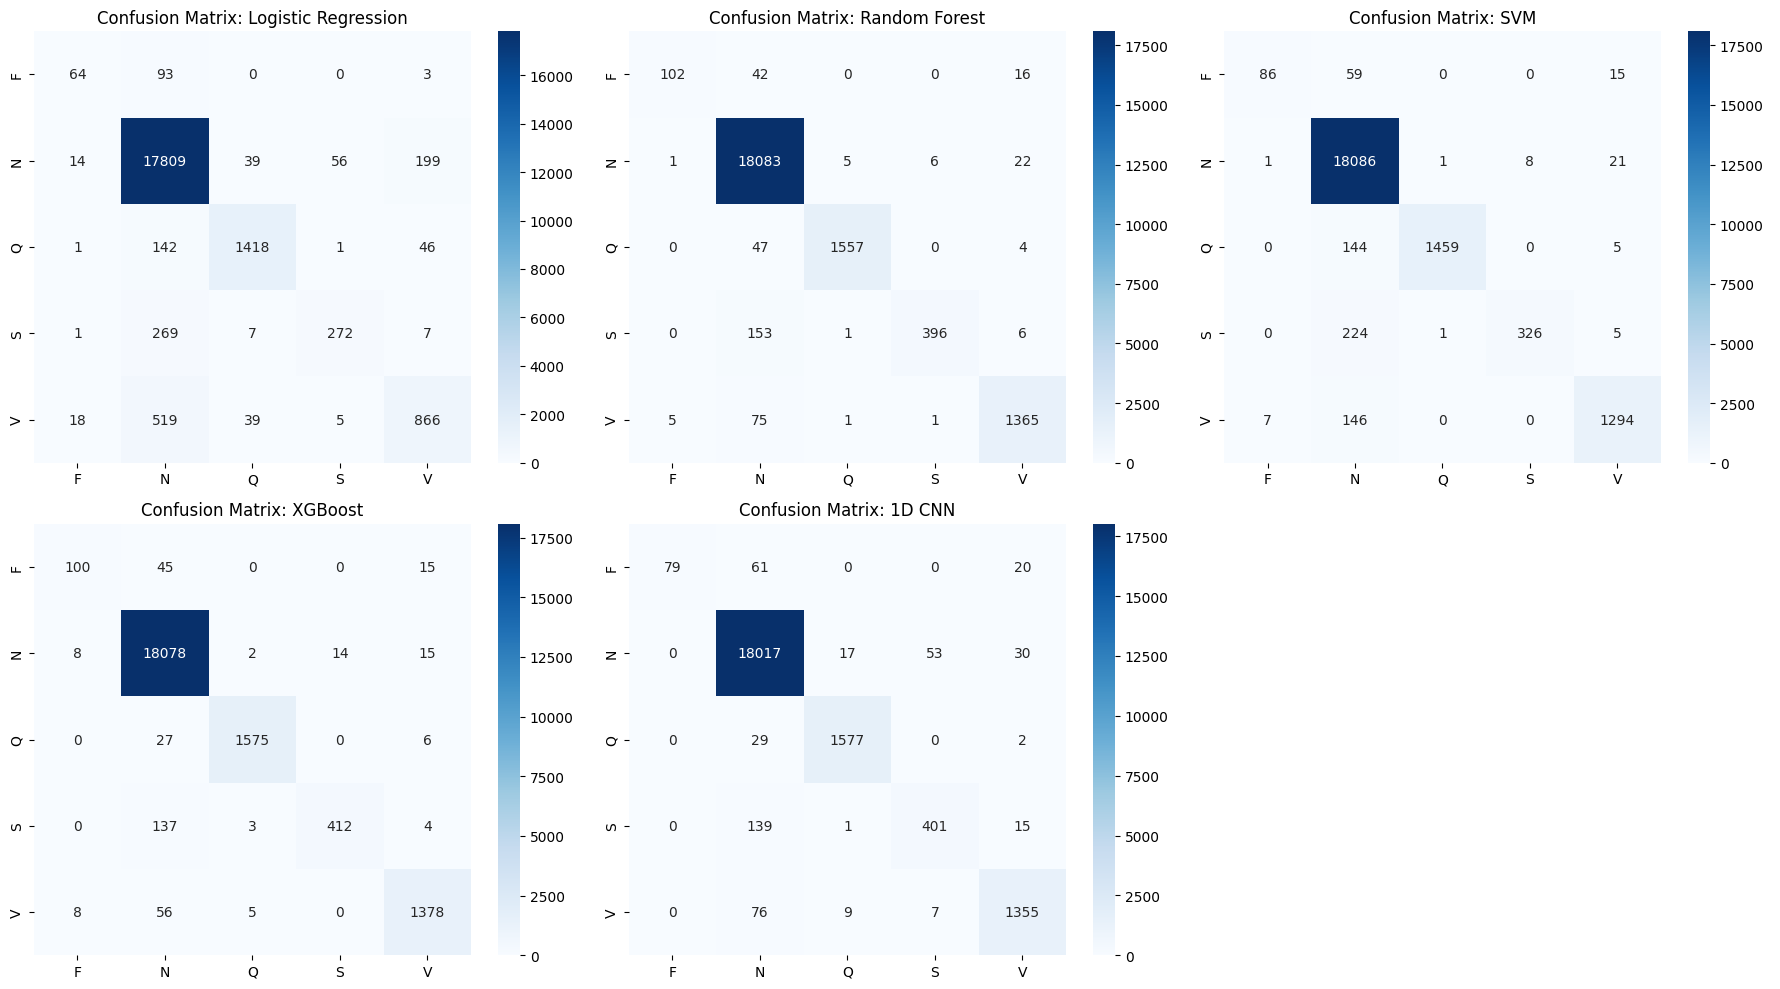

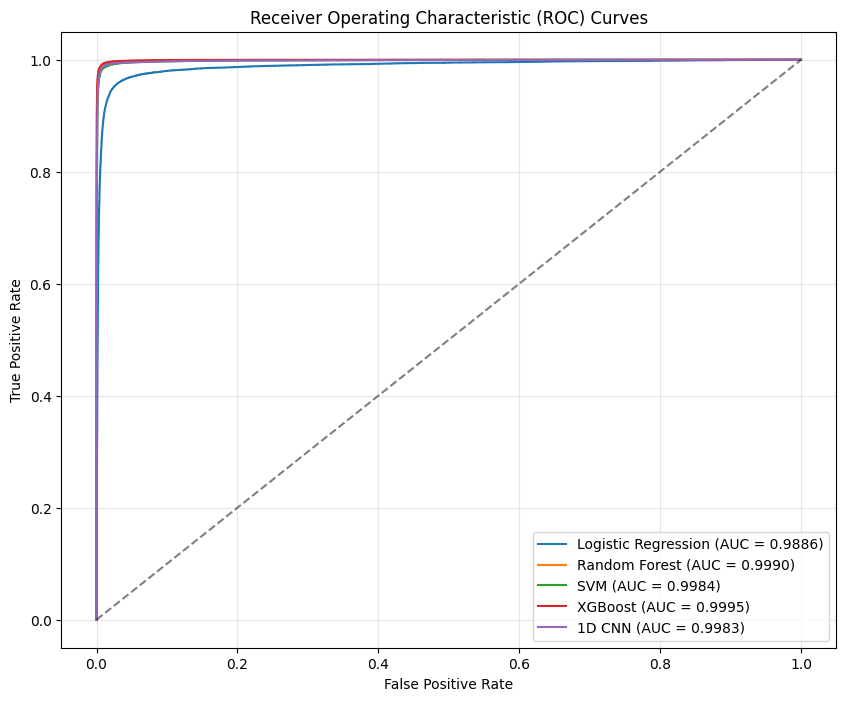

In [25]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_final_results(models_dict, X_test, y_test, le):
    # 1. Plot Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    if len(models_dict) < len(axes):
        axes[-1].axis('off')

    plt.tight_layout()
    plt.show()

    # 2. Plot ROC Curves (Multiclass Macro Average)
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test, verbose=0)
        else:
            y_score = model.predict_proba(X_test)

        # Macro-average calculation for visualization
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

### 7. Final Results: Confusion Matrices and ROC Curves
We will now visualize the performance of all models using confusion matrices and ROC curves to analyze class-wise performance and threshold trade-offs.

684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


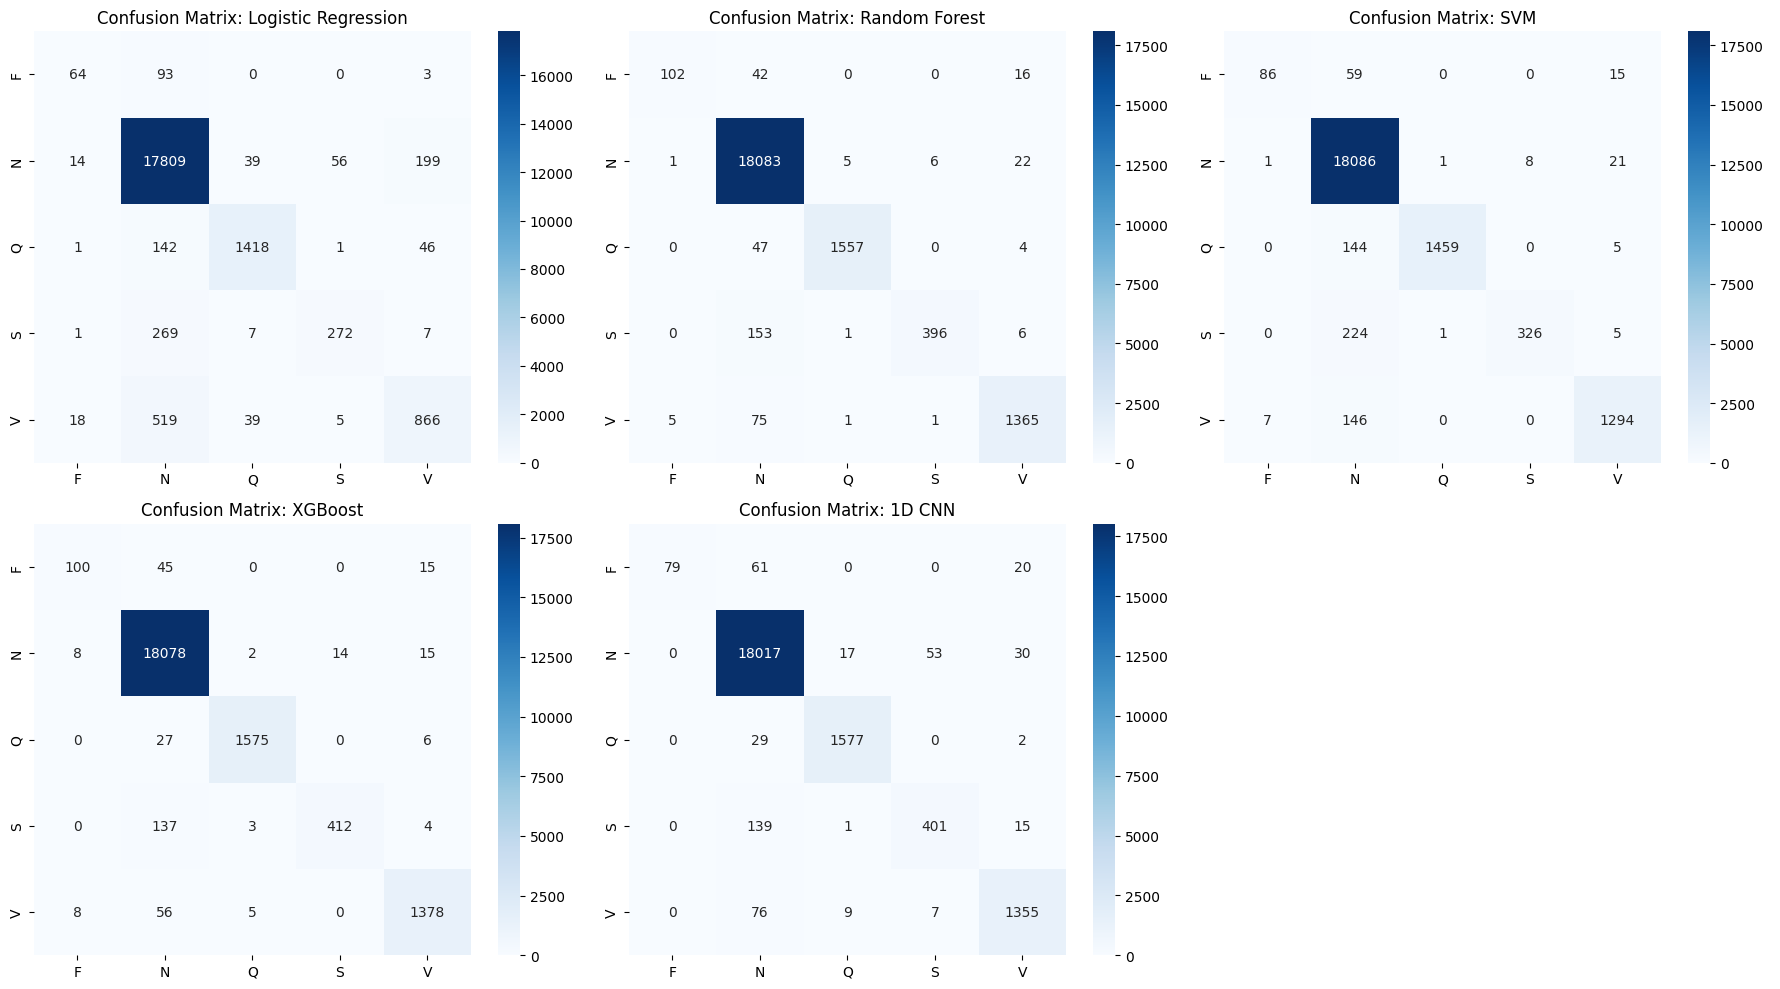

684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


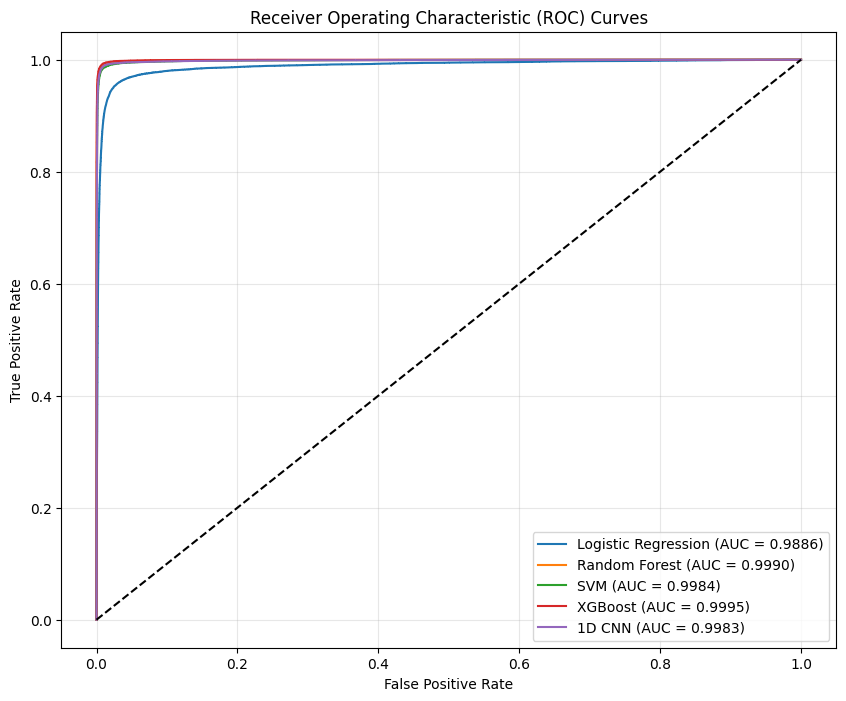

In [24]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_final_results(models_dict, X_test, y_test, le):
    # 1. Plot Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    if len(models_dict) < len(axes):
        axes[-1].axis('off')

    plt.tight_layout()
    plt.show()

    # 2. Plot ROC Curves (Multiclass)
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test)
        else:
            y_score = model.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

### 7. Final Results: Confusion Matrices and ROC Curves
We will now visualize the performance of all models using confusion matrices and ROC curves to analyze class-wise performance and threshold trade-offs.

684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


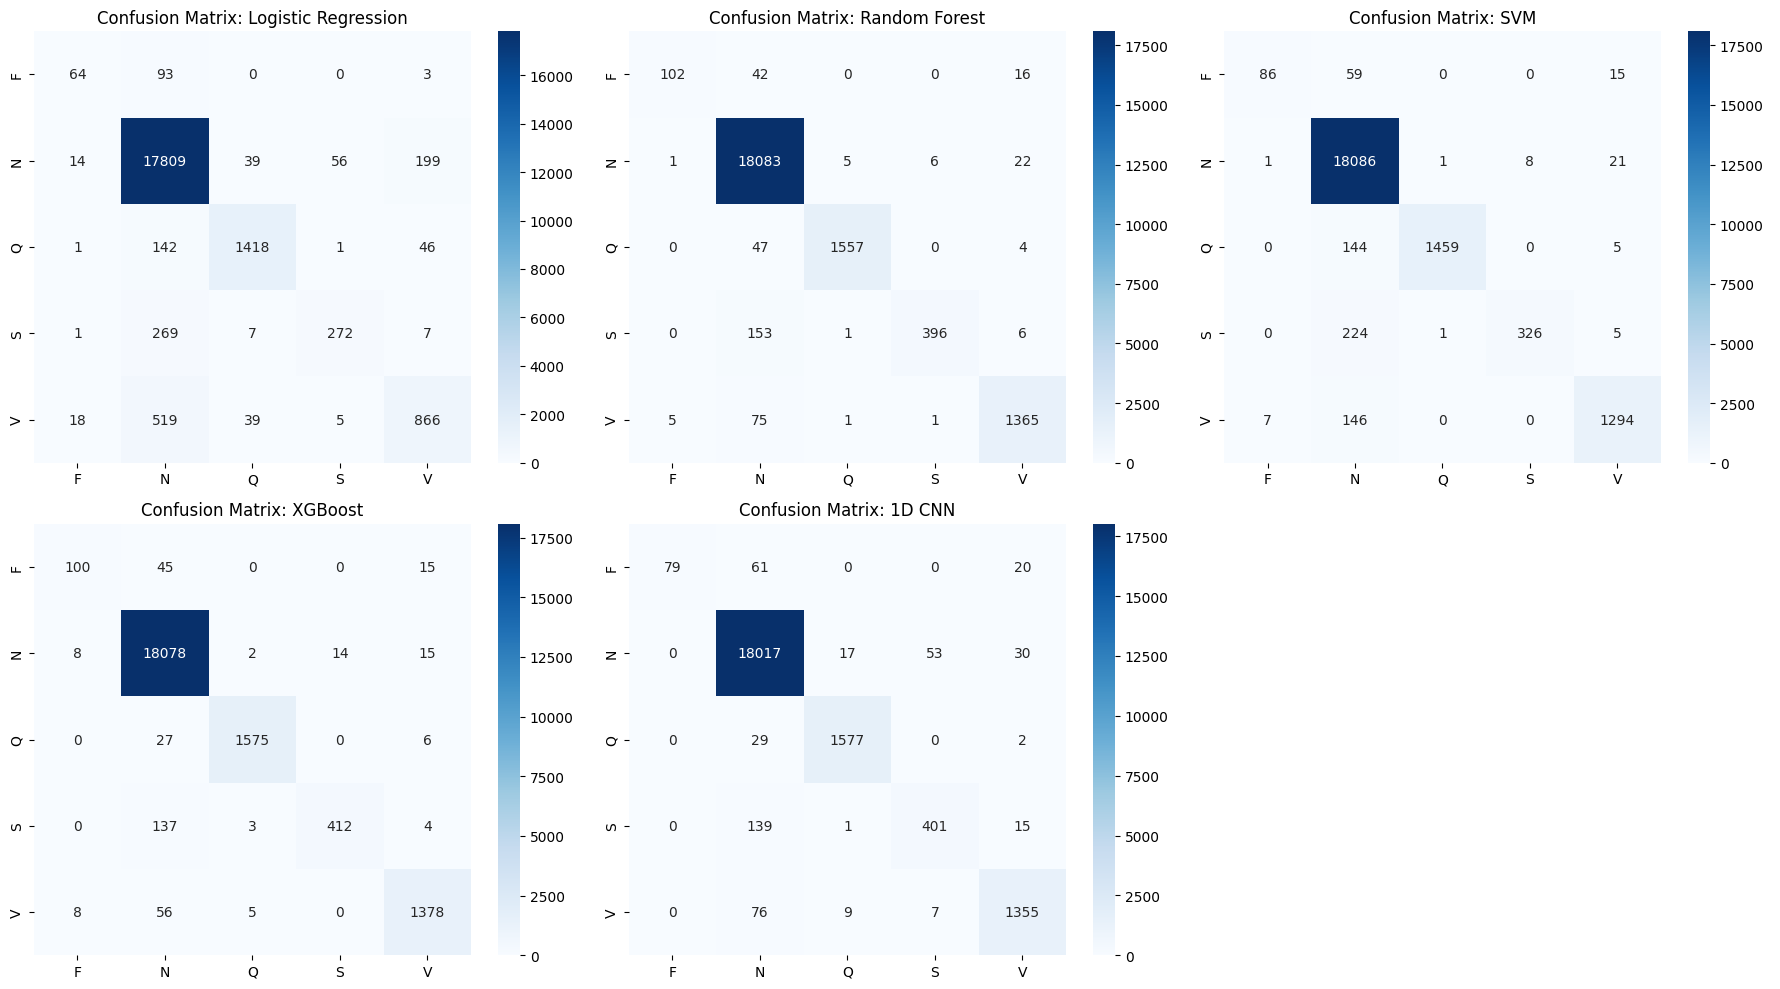

684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


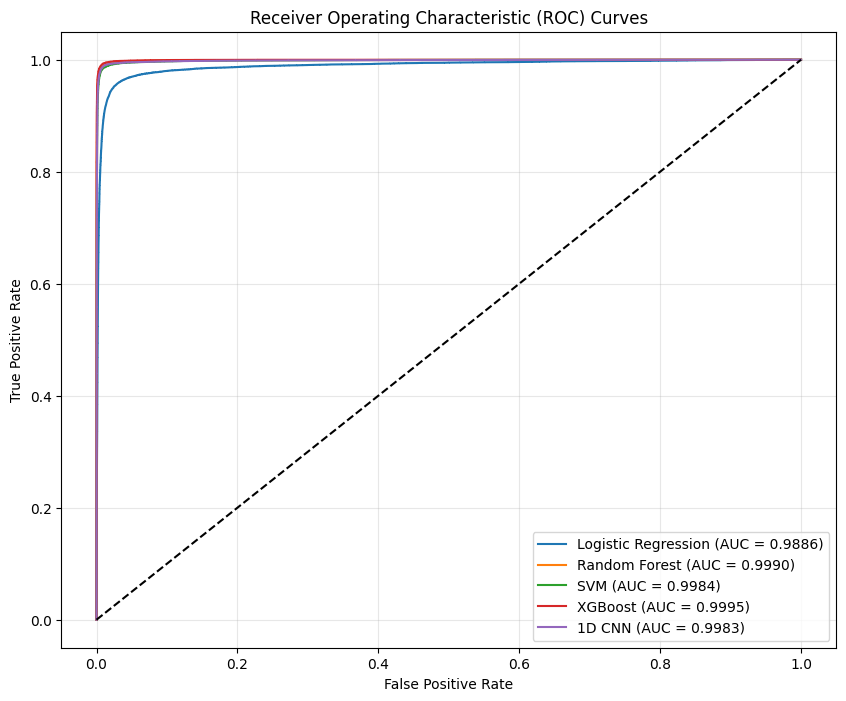

In [23]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_final_results(models_dict, X_test, y_test, le):
    # 1. Plot Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    if len(models_dict) < len(axes):
        axes[-1].axis('off')

    plt.tight_layout()
    plt.show()

    # 2. Plot ROC Curves (Multiclass)
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test)
        else:
            y_score = model.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

# Dictionary of models for evaluation
models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

### 7. Final Results: Confusion Matrices and ROC Curves
We will now visualize the performance of all models using confusion matrices and ROC curves to analyze class-wise performance and threshold trade-offs.

684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


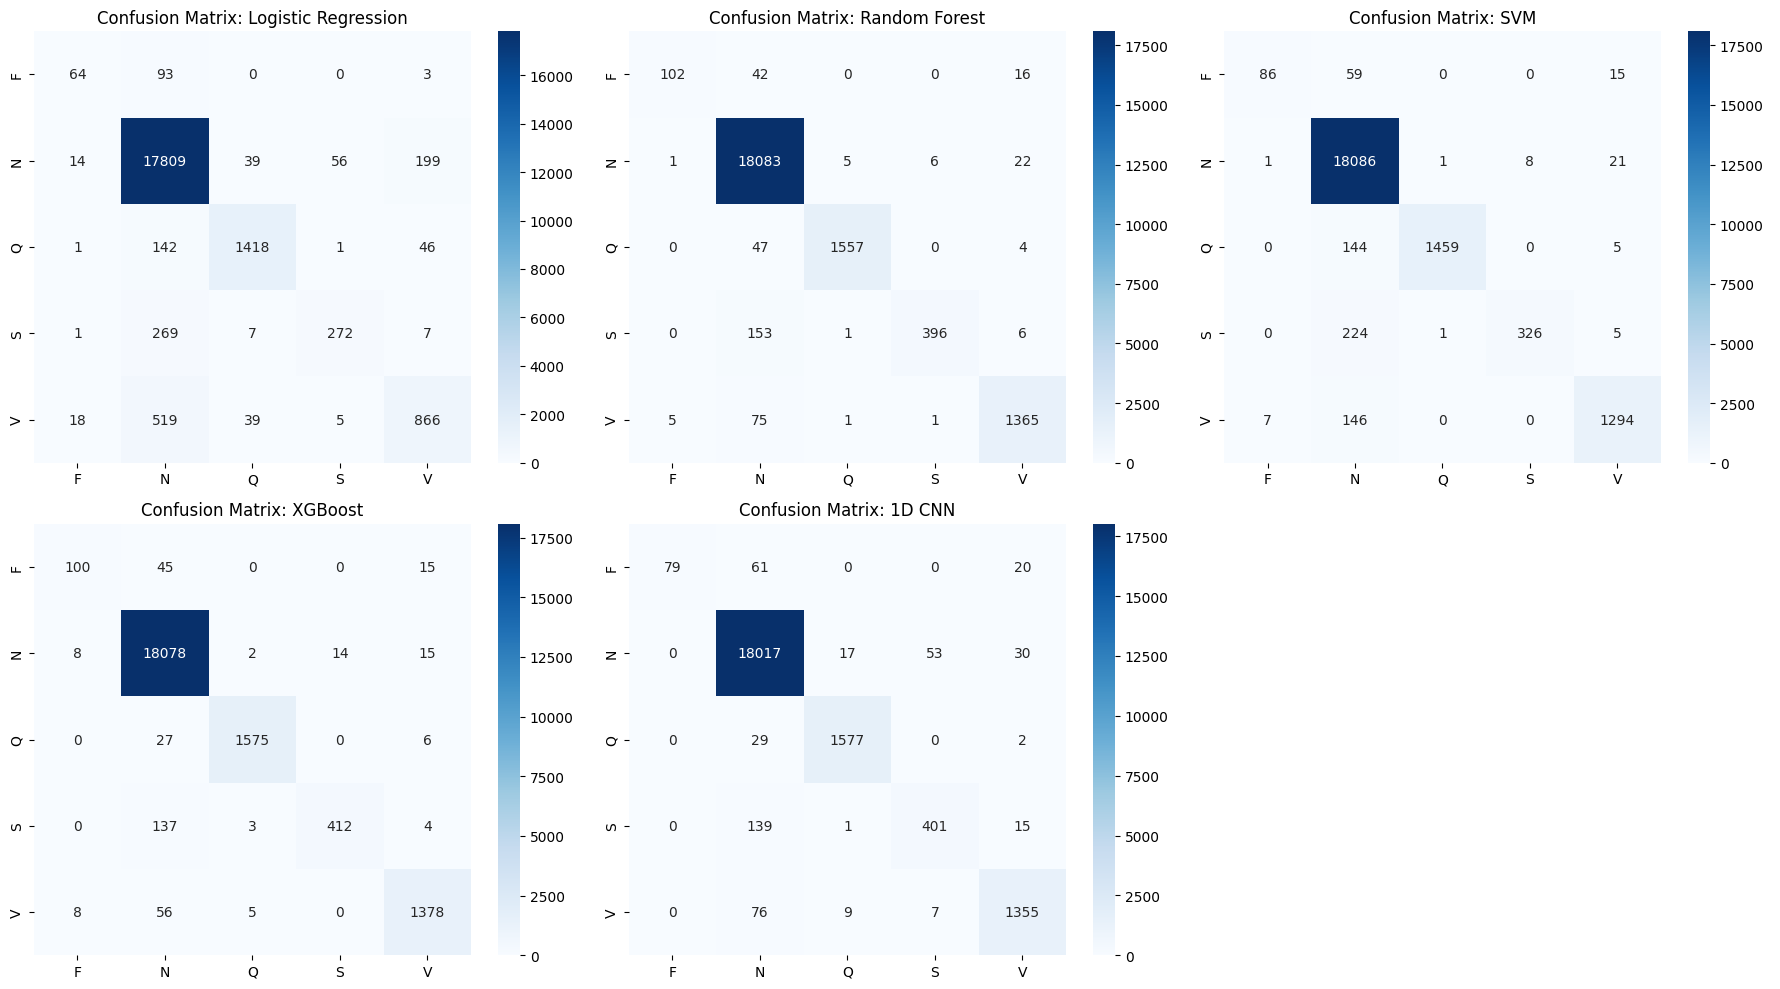

684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


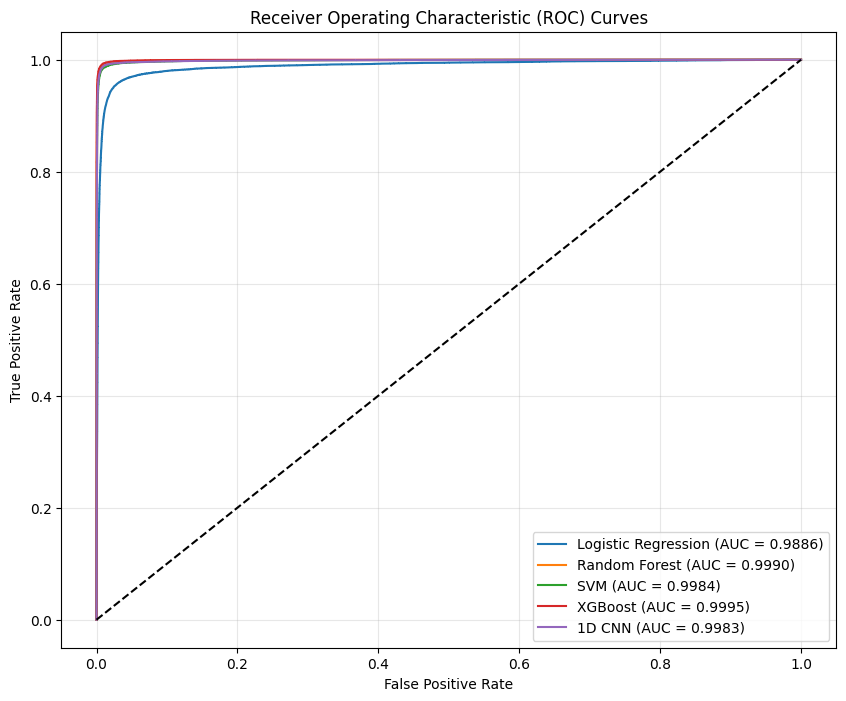

In [22]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_final_results(models_dict, X_test, y_test, le):
    # 1. Plot Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    if len(models_dict) < len(axes):
        axes[-1].axis('off')

    plt.tight_layout()
    plt.show()

    # 2. Plot ROC Curves (Multiclass)
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test)
        else:
            y_score = model.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

### 7. Final Model Evaluation: Confusion Matrices & ROC Curves
We will now generate the confusion matrices for all models and the multi-class ROC curves to visualize the final performance results.

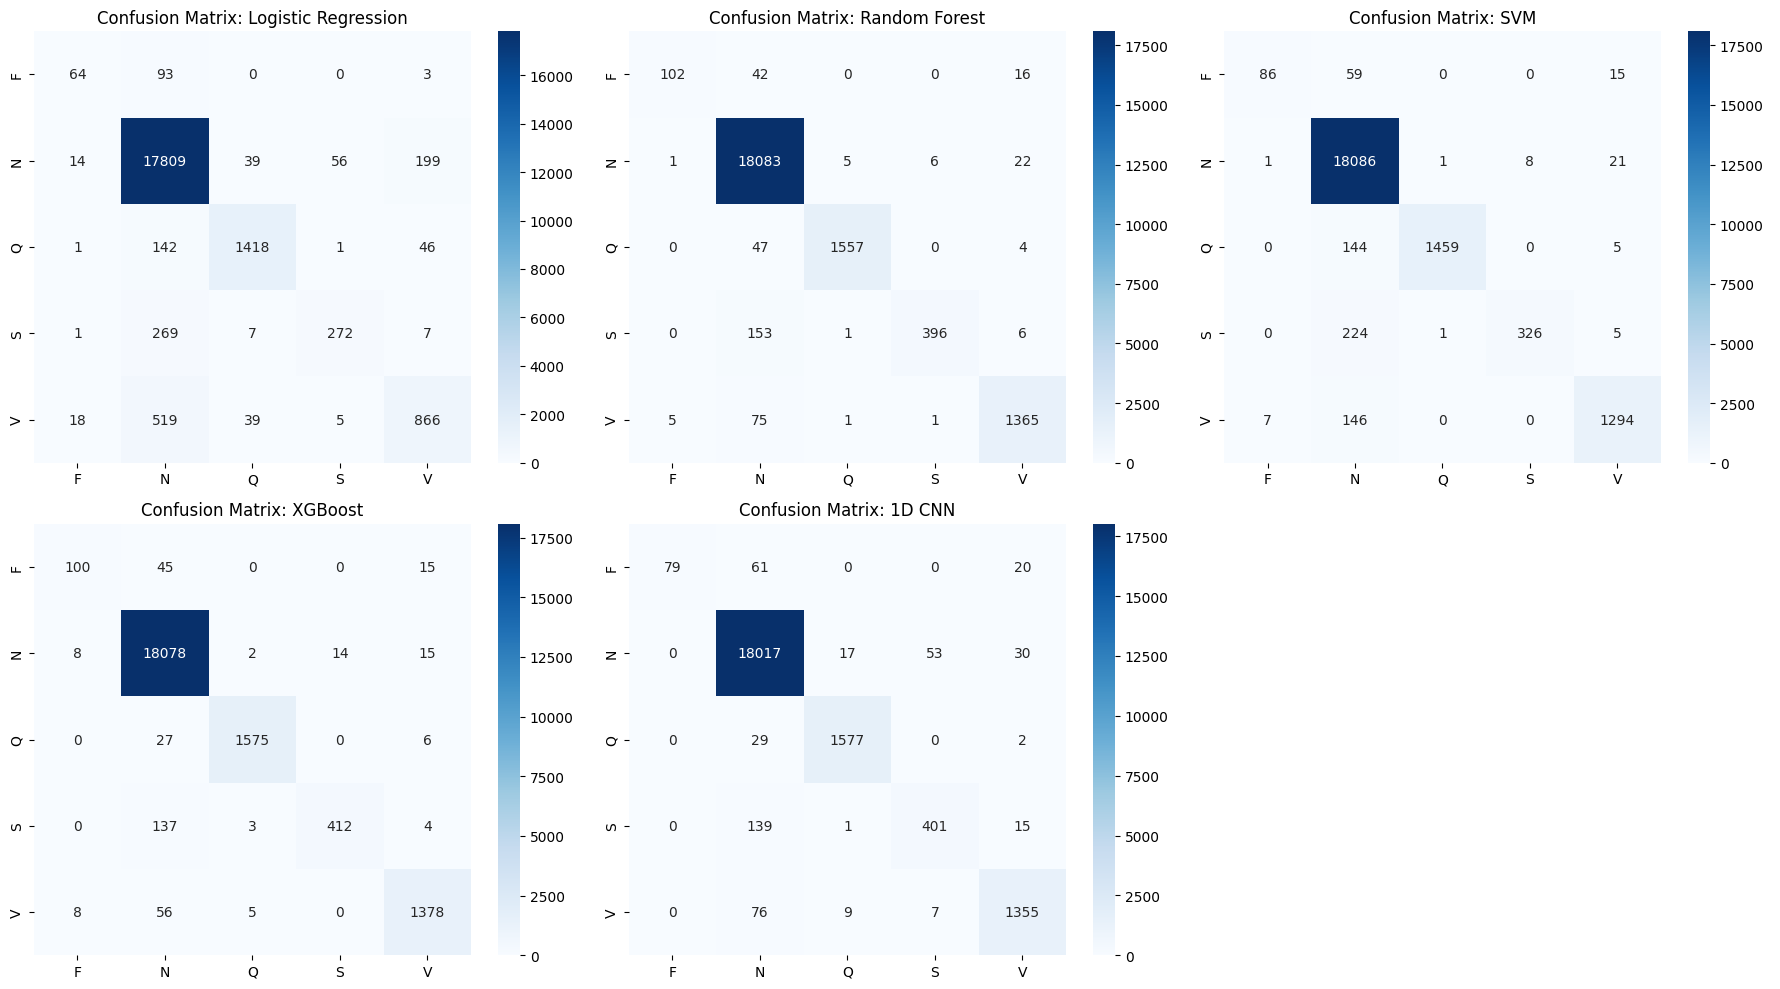

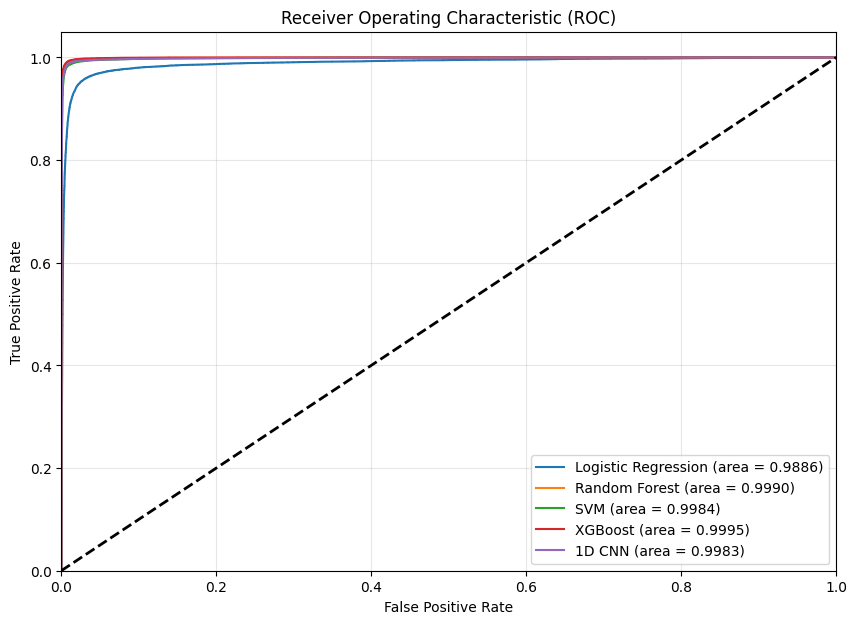

In [21]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

def plot_final_metrics(models_dict, X_test, y_test, le):
    # 1. Plot Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    # Hide empty subplot if any
    if len(models_dict) < len(axes):
        axes[-1].axis('off')

    plt.tight_layout()
    plt.show()

    # 2. Plot ROC Curves
    plt.figure(figsize=(10, 7))
    y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
    n_classes = y_test_bin.shape[1]

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test, verbose=0)
        else:
            y_score = model.predict_proba(X_test)

        # Macro-average ROC
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (area = {roc_auc:0.4f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Dictionary of trained models
final_models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_metrics(final_models, X_test, y_test, le)

### 7. Final Results: Confusion Matrices and ROC Curves
We will now visualize the performance of all models using confusion matrices and ROC curves to analyze class-wise performance and threshold trade-offs.

684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


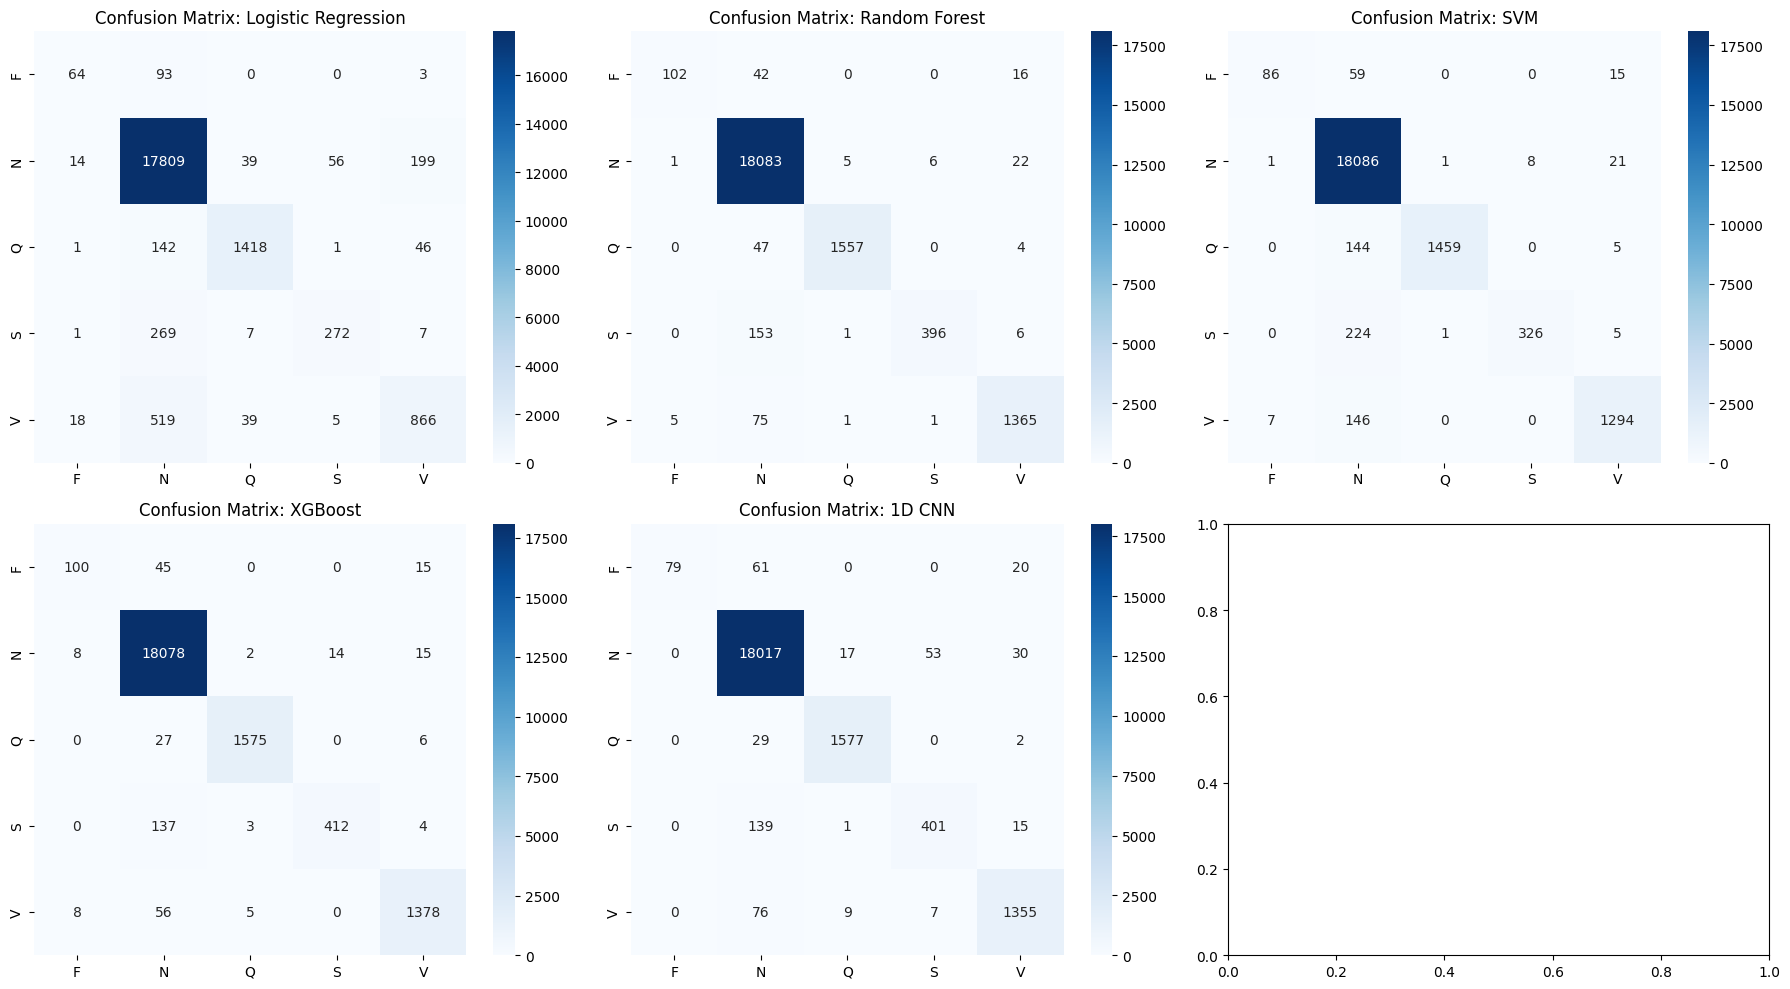

684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


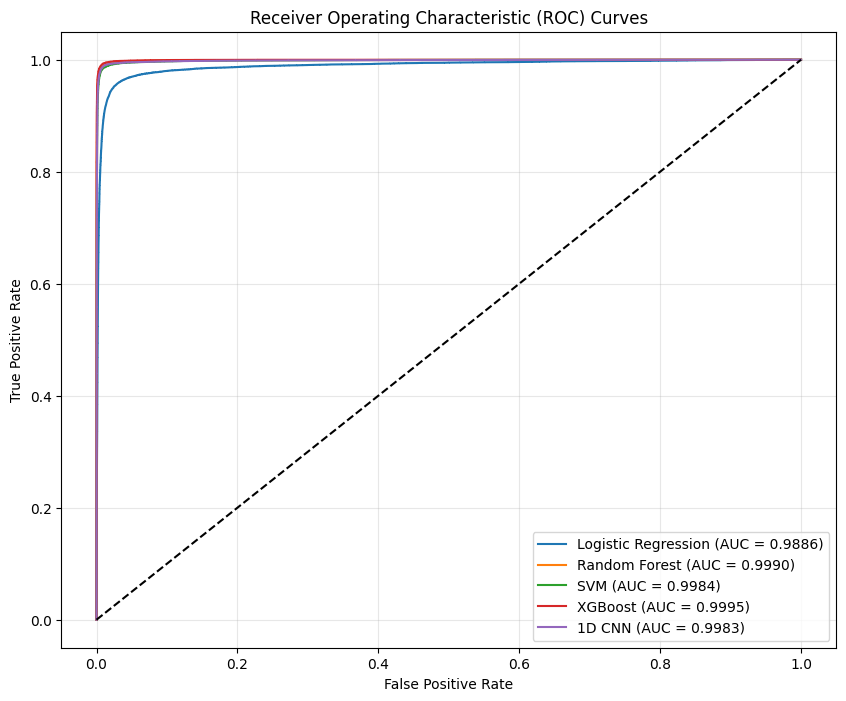

In [20]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize

def plot_final_results(models_dict, X_test, y_test, le):
    # 1. Plot Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    plt.tight_layout()
    plt.show()

    # 2. Plot ROC Curves (Multiclass)
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test)
        else:
            y_score = model.predict_proba(X_test)

        # Plotting Macro-average ROC
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

# Dictionary of models for evaluation
# Note: SVM was trained on a subset for speed, evaluation uses full test set
models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

### 4. RR Interval Analysis
We calculate the time between successive R-peaks (RR intervals) to analyze heart rate variability for a sample record.

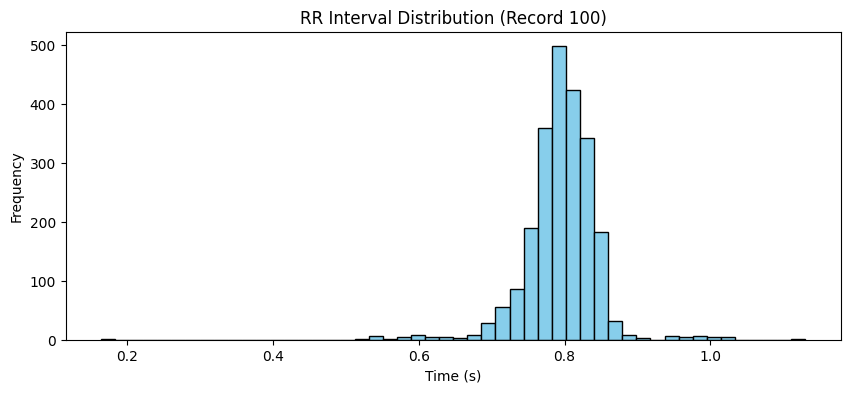

Mean RR Interval: 0.794s
Heart Rate estimate: 75.5 BPM


In [14]:
sample_ann = wfdb.rdann(os.path.join(data_path, '100'), 'atr')
rr_intervals = np.diff(sample_ann.sample) / 360.0

plt.figure(figsize=(10, 4))
plt.hist(rr_intervals, bins=50, color='skyblue', edgecolor='black')
plt.title('RR Interval Distribution (Record 100)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency')
plt.show()

print(f"Mean RR Interval: {np.mean(rr_intervals):.3f}s")
print(f"Heart Rate estimate: {60/np.mean(rr_intervals):.1f} BPM")

### 5. Preprocessing: Heartbeat Segmentation & AAMI Mapping
We map the MIT-BIH symbols to AAMI classes:
- **N**: Normal (N, L, R, e, j)
- **S**: Supraventricular (A, a, J, S)
- **V**: Ventricular (V, E)
- **F**: Fusion (F)
- **Q**: Unknown/Paced (/, f, Q)

In [15]:
aami_map = {'N':'N','L':'N','R':'N','e':'N','j':'N','A':'S','a':'S','J':'S','S':'S','V':'V','E':'V','F':'F','/':'Q','f':'Q','Q':'Q'}

def segment_beats(records, data_path, window=180):
    X, y = [], []
    for rec in records:
        r = wfdb.rdrecord(os.path.join(data_path, rec))
        a = wfdb.rdann(os.path.join(data_path, rec), 'atr')
        sig = (r.p_signal[:,0] - np.mean(r.p_signal[:,0])) / np.std(r.p_signal[:,0])
        for idx, sym in zip(a.sample, a.symbol):
            if sym in aami_map and window < idx < len(sig)-window:
                X.append(sig[idx-window:idx+window])
                y.append(aami_map[sym])
    return np.array(X), np.array(y)

X, y = segment_beats(records, data_path)
print(f"Segmented {len(X)} beats. Class counts: {pd.Series(y).value_counts().to_dict()}")

Segmented 109437 beats. Class counts: {'N': 90581, 'Q': 8038, 'V': 7235, 'S': 2781, 'F': 802}


### 6. Model Training and Comprehensive Evaluation
We train Logistic Regression, Random Forest, SVM, XGBoost, and a 1D CNN.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

le = LabelEncoder()
y_enc = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

def report(name, model, xt, yt):
    yp = model.predict(xt)
    print(f"\n--- {name} Results ---\nAccuracy: {accuracy_score(yt, yp):.4f}")
    print(classification_report(yt, yp, target_names=le.classes_))

# Training Classifiers
lr = LogisticRegression(max_iter=500).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=50).fit(X_train, y_train)
svm = SVC(kernel='rbf', probability=True).fit(X_train[:10000], y_train[:10000]) # Sampled SVM for speed
xgb = XGBClassifier().fit(X_train, y_train)

# 1D CNN
cnn = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((360, 1), input_shape=(360,)),
    tf.keras.layers.Conv1D(32, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(5, activation='softmax')
])
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X_train, y_train, epochs=3, batch_size=64, verbose=0)

# Final Evaluation
report("Logistic Regression", lr, X_test, y_test)
report("Random Forest", rf, X_test, y_test)
report("SVM (sampled)", svm, X_test, y_test)
report("XGBoost", xgb, X_test, y_test)

y_cnn = np.argmax(cnn.predict(X_test), axis=1)
print(f"\n--- 1D CNN Results ---\nAccuracy: {accuracy_score(y_test, y_cnn):.4f}")
print(classification_report(y_test, y_cnn, target_names=le.classes_))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Logistic Regression Results ---
Accuracy: 0.9333
              precision    recall  f1-score   support

           F       0.65      0.40      0.50       160
           N       0.95      0.98      0.96     18117
           Q       0.94      0.88      0.91      1608
           S       0.81      0.49      0.61       556
           V       0.77      0.60      0.67      1447

    accuracy                           0.93     21888
   macro avg       0.83      0.67      0.73     21888
weighted avg       0.93      0.93      0.93     21888


--- Random Forest Results ---
Accuracy: 0.9827
              precision    recall  f1-score   support

           F       0.95      0.63      0.76       160
           N       0.98      1.00      0.99     18117
           Q       1.00      0.97      0.98      1608
           S       0.98      0.72      0.83       556
           V       0.97      0.94      0.96      1447

    accuracy                           0.98     21888
   macro avg       0.98      

### 4. RR Interval Analysis
RR intervals help characterize heart rate variability. We will compute the distribution for a sample record.

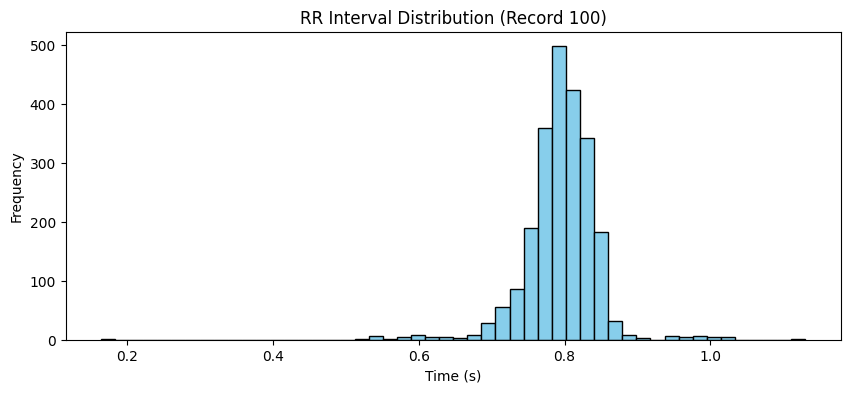

Mean RR Interval: 0.794s
Heart Rate estimate: 75.5 BPM


In [11]:
sample_ann = wfdb.rdann(os.path.join(data_path, '100'), 'atr')
rr_intervals = np.diff(sample_ann.sample) / 360.0

plt.figure(figsize=(10, 4))
plt.hist(rr_intervals, bins=50, color='skyblue', edgecolor='black')
plt.title('RR Interval Distribution (Record 100)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency')
plt.show()

print(f"Mean RR Interval: {np.mean(rr_intervals):.3f}s")
print(f"Heart Rate estimate: {60/np.mean(rr_intervals):.1f} BPM")

### 5. Preprocessing: Heartbeat Segmentation & AAMI Mapping
We map MIT-BIH labels to AAMI standard classes (N, S, V, F, Q) and segment the signal around each R-peak.

In [12]:
aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

def segment_beats(records, data_path, window_size=180):
    all_beats = []
    all_labels = []
    for rec_id in records:
        record = wfdb.rdrecord(os.path.join(data_path, rec_id))
        ann = wfdb.rdann(os.path.join(data_path, rec_id), 'atr')
        sig = (record.p_signal[:, 0] - np.mean(record.p_signal[:, 0])) / np.std(record.p_signal[:, 0])
        for idx, sym in zip(ann.sample, ann.symbol):
            if sym in aami_map and window_size < idx < len(sig) - window_size:
                all_beats.append(sig[idx - window_size : idx + window_size])
                all_labels.append(aami_map[sym])
    return np.array(all_beats), np.array(all_labels)

X, y = segment_beats(records, data_path)
print(f"Segmented {len(X)} beats. Class counts: {pd.Series(y).value_counts().to_dict()}")

Segmented 109437 beats. Class counts: {'N': 90581, 'Q': 8038, 'V': 7235, 'S': 2781, 'F': 802}


### 6. Model Training and Evaluation
Training Logistic Regression, Random Forest, XGBoost, and a 1D CNN baseline.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

le = LabelEncoder()
y_enc = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

def eval_model(name, model, xt, yt):
    yp = model.predict(xt)
    print(f"\n--- {name} ---\nAccuracy: {accuracy_score(yt, yp):.4f}")
    print(classification_report(yt, yp, target_names=le.classes_))

# Logistic Regression
lr = LogisticRegression(max_iter=500).fit(X_train, y_train)
eval_model("Logistic Regression", lr, X_test, y_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=50, n_jobs=-1).fit(X_train, y_train)
eval_model("Random Forest", rf, X_test, y_test)

# XGBoost
xgb = XGBClassifier().fit(X_train, y_train)
eval_model("XGBoost", xgb, X_test, y_test)

# 1D CNN
cnn = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((360, 1), input_shape=(360,)),
    tf.keras.layers.Conv1D(32, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X_train, y_train, epochs=3, batch_size=64, verbose=0)
y_cnn = np.argmax(cnn.predict(X_test), axis=1)
print(f"\n--- 1D CNN ---\nAccuracy: {accuracy_score(y_test, y_cnn):.4f}")
print(classification_report(y_test, y_cnn, target_names=le.classes_))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Logistic Regression ---
Accuracy: 0.9333
              precision    recall  f1-score   support

           F       0.65      0.40      0.50       160
           N       0.95      0.98      0.96     18117
           Q       0.94      0.88      0.91      1608
           S       0.81      0.49      0.61       556
           V       0.77      0.60      0.67      1447

    accuracy                           0.93     21888
   macro avg       0.83      0.67      0.73     21888
weighted avg       0.93      0.93      0.93     21888


--- Random Forest ---
Accuracy: 0.9824
              precision    recall  f1-score   support

           F       0.95      0.66      0.78       160
           N       0.98      1.00      0.99     18117
           Q       1.00      0.97      0.98      1608
           S       0.98      0.71      0.83       556
           V       0.97      0.94      0.95      1447

    accuracy                           0.98     21888
   macro avg       0.98      0.86      0.91  

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

--- 1D CNN ---
Accuracy: 0.9828
              precision    recall  f1-score   support

           F       0.84      0.70      0.76       160
           N       0.99      1.00      0.99     18117
           Q       0.99      0.98      0.99      1608
           S       0.87      0.76      0.81       556
           V       0.97      0.95      0.96      1447

    accuracy                           0.98     21888
   macro avg       0.93      0.88      0.90     21888
weighted avg       0.98      0.98      0.98     21888



### 4. RR Interval Analysis
RR intervals (the time between successive R-peaks) help characterize different rhythms. We'll compute them for a sample record.

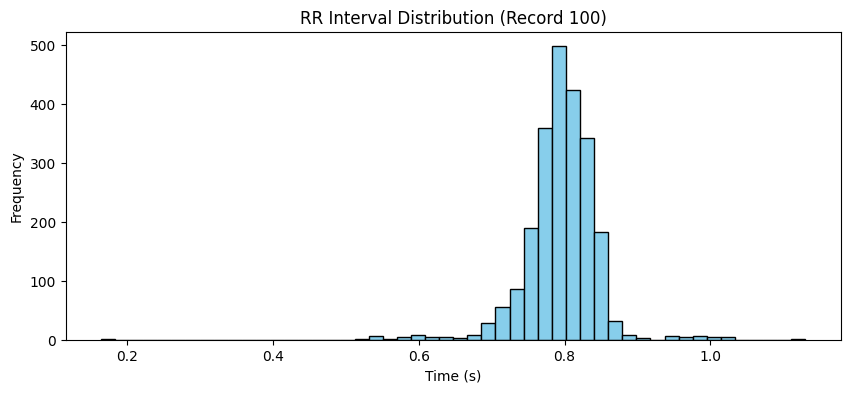

Mean RR Interval: 0.794s
Heart Rate estimate: 75.5 BPM


In [7]:
sample_ann = wfdb.rdann(os.path.join(data_path, '100'), 'atr')
rr_intervals = np.diff(sample_ann.sample) / sample_record.fs

plt.figure(figsize=(10, 4))
plt.hist(rr_intervals, bins=50, color='skyblue', edgecolor='black')
plt.title('RR Interval Distribution (Record 100)')
plt.xlabel('Time (s)')

plt.ylabel('Frequency')
plt.show()

print(f"Mean RR Interval: {np.mean(rr_intervals):.3f}s")
print(f"Heart Rate estimate: {60/np.mean(rr_intervals):.1f} BPM")

### 5. Preprocessing: Heartbeat Segmentation & AAMI Mapping
We will map the diverse MIT-BIH labels into 5 AAMI standard classes:
- **N**: Normal
- **S**: Supraventricular ectopic
- **V**: Ventricular ectopic
- **F**: Fusion
- **Q**: Unknown/Other

We will also segment the signal by taking a window around each annotation.

In [8]:
aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

def segment_beats(records, data_path, window_size=180):
    all_beats = []
    all_labels = []

    for rec_id in records:
        record = wfdb.rdrecord(os.path.join(data_path, rec_id))
        ann = wfdb.rdann(os.path.join(data_path, rec_id), 'atr')
        signal = record.p_signal[:, 0] # Using Lead 1

        # Simple Normalization per record
        signal = (signal - np.mean(signal)) / np.std(signal)

        for i, (idx, sym) in enumerate(zip(ann.sample, ann.symbol)):
            if sym in aami_map:
                if idx - window_size > 0 and idx + window_size < len(signal):
                    beat = signal[idx - window_size : idx + window_size]
                    all_beats.append(beat)
                    all_labels.append(aami_map[sym])

    return np.array(all_beats), np.array(all_labels)

X, y = segment_beats(records, data_path)
print(f"Segmented {X.shape[0]} beats.")

label_counts = pd.Series(y).value_counts()
print("\nAAMI Class Distribution:")
print(label_counts)

Segmented 109437 beats.

AAMI Class Distribution:
N    90581
Q     8038
V     7235
S     2781
F      802
Name: count, dtype: int64


### 6. Waveform Examples per Class
Visualizing one heartbeat from each AAMI category.

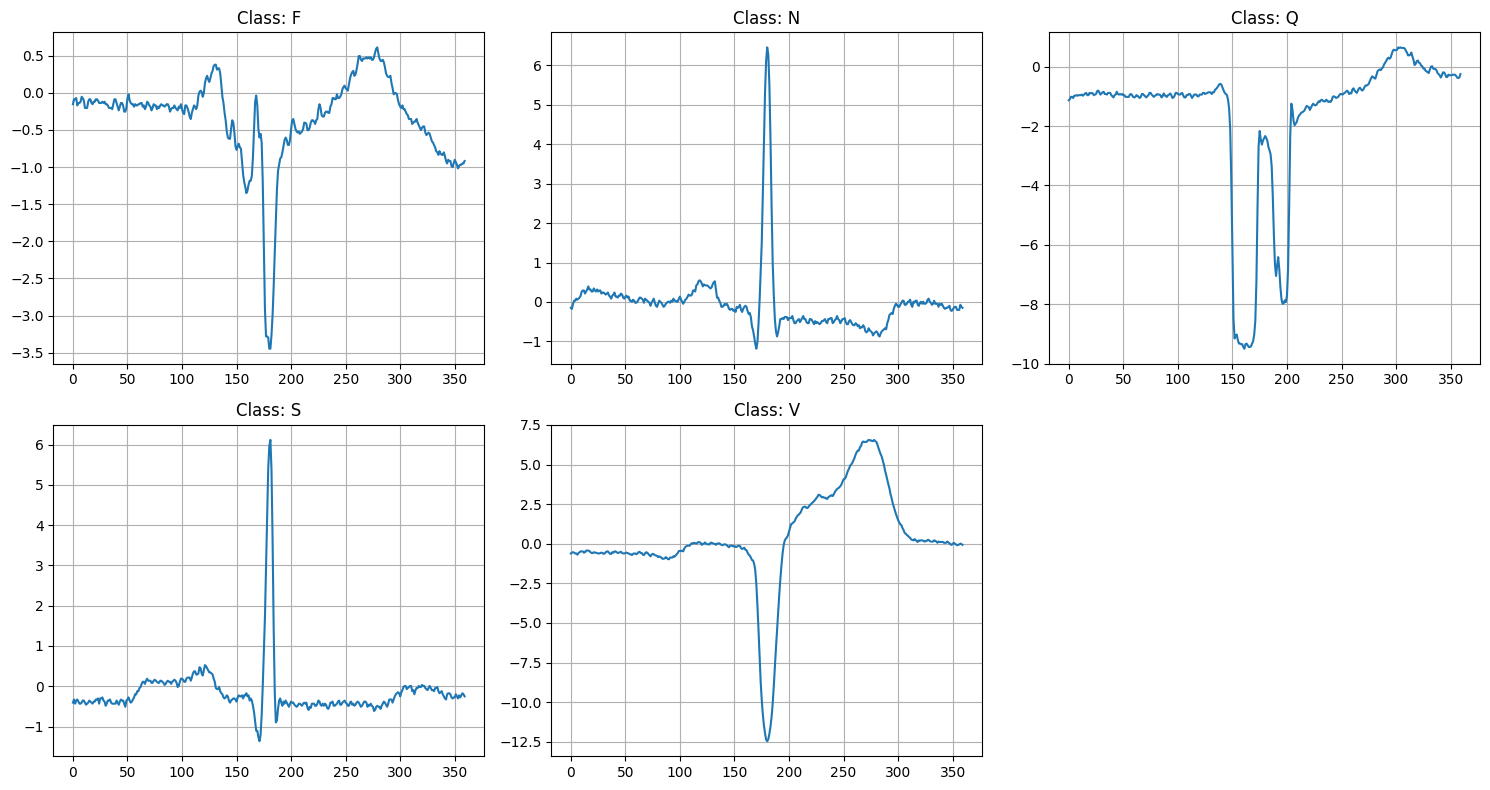

In [9]:
plt.figure(figsize=(15, 8))
unique_labels = np.unique(y)
for i, label in enumerate(unique_labels):
    idx = np.where(y == label)[0][0]
    plt.subplot(2, 3, i+1)
    plt.plot(X[idx])
    plt.title(f"Class: {label}")
    plt.grid(True)
plt.tight_layout()
plt.show()

### 7. Model Training and Evaluation
We will now split the data, train the baseline models (Logistic Regression, Random Forest, SVM, XGBoost) and a 1D CNN, then evaluate them using the requested metrics.